<div style="background-color: #013a63; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    CSCA 5642 - Introduction to Deep Learning - Final Project
</div>

<div style="background-color: magenta; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Stock Market Price Pridiction and Direction Prediction
</div>

#### Project Overview: Stock Market Prediction using Deep Learning

This project aims to predict stock market price movements using deep learning techniques. We will explore both price value prediction and directional movement prediction (up or down).

Here is a breakdown of the steps involved:

**1. Data Collection:**
*   **Source:** We will fetch historical stock data using the Alpaca API.
*   **Features:** The dataset will include Open, High, Low, Close prices, and Volume (OHLCV).
*   **Target:** We will select a specific stock or index to focus on, for example, SPY (S&P 500 ETF) or a major tech stock like NVDA.

**2. Data Preprocessing and Feature Engineering:**
*   **Data Cleaning:** Handle any missing values in the dataset.
*   **Feature Scaling:** Normalize the data, particularly the price and volume, to a range (e.g., 0 to 1) using `MinMaxScaler`. This is crucial for neural network performance.
*   **Technical Indicators:** Engineer new features by calculating technical indicators. These can provide valuable signals for the model. Examples include:
    *   Moving Averages (SMA, EMA)
    *   Relative Strength Index (RSI)
    *   Moving Average Convergence Divergence (MACD)
*   **Sequence Creation:** Transform the time-series data into sequences of a fixed length (e.g., use the last 60 days of data to predict the next day).

**3. Model Selection:**
For time-series forecasting, Recurrent Neural Networks (RNNs) are a strong choice.
*   **LSTM (Long Short-Term Memory):** This is an excellent starting point. LSTMs are designed to remember long-term dependencies, which is perfect for financial time-series data.
*   **GRU (Gated Recurrent Unit):** A variation of LSTM, which is slightly simpler and can be faster to train. It's worth experimenting with as it can sometimes yield better results on certain datasets.
*   **Hybrid Models (e.g., CNN-LSTM):** A Convolutional Neural Network (CNN) can be used to extract features from the input sequences before feeding them into an LSTM. This can sometimes improve performance.

We will start with an LSTM model.

**4. Model Training:**
*   **Data Splitting:** Split the data chronologically into training, validation, and testing sets. A common split is 80% for training, 10% for validation, and 10% for testing.
*   **Model Architecture:** Define the layers of the LSTM network (e.g., number of LSTM layers, number of neurons, dropout layers for regularization).
*   **Compilation:**
    *   **Loss Function:** For price prediction, we'll use a regression loss like `Mean Squared Error (MSE)`. For direction prediction, we'll use `Binary Cross-Entropy`.
    *   **Optimizer:** `Adam` is generally a good choice.
*   **Training:** Train the model on the training data while monitoring its performance on the validation data to prevent overfitting.

**5. Model Evaluation:**
*   **Price Prediction Metrics:** Evaluate the model on the test set using metrics like:
    *   Root Mean Squared Error (RMSE)
    *   Mean Absolute Error (MAE)
*   **Direction Prediction Metrics:**
    *   Accuracy
    *   Precision, Recall, F1-Score
    *   Confusion Matrix
*   **Visualization:** Plot the predicted prices against the actual prices to visually inspect the model's performance.

**6. Conclusion and Future Work:**
*   Summarize the results and the performance of the model.
*   Discuss potential improvements, such as:
    *   Hyperparameter tuning.
    *   Trying different model architectures.
    *   Incorporating sentiment analysis from financial news.
    *   Applying the model to other stocks or markets.


<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Dataset Description - Alpaca Datafeed
</div>

Alpaca is a modern platform for algorithmic trading that provides a powerful API for accessing real-time and historical market data. The Alpaca Data API is a key component for developers and traders who need reliable and fast access to stock market data.

### Key Features of Alpaca's Datafeed:

*   **Broad Coverage:** Alpaca provides data for a wide range of U.S. equities. You can access data for major stocks like **NVIDIA (NVDA)**, a leading technology company known for its GPUs, as well as Exchange-Traded Funds (ETFs) like **SPY**, which tracks the S&P 500 index.
*   **Real-Time and Historical Data:** You can get up-to-the-minute data for active trading or fetch historical data going back several years for backtesting and analysis.
*   **Data Format (OHLCV):** The data is typically provided in the standard OHLCV format:
    *   **Open:** The price at the beginning of the time interval.
    *   **High:** The highest price during the interval.
    *   **Low:** The lowest price during the interval.
    *   **Close:** The price at the end of the time interval.
    *   **Volume:** The number of shares traded during the interval.
*   **Flexible Timeframes:** The API allows you to specify the timeframe for the data bars, such as:
    *   `1Min` for minute-level data.
    *   `1Day` for daily data.
    *   `1Week` for weekly data.
*   **Easy Integration:** The data can be easily integrated into Python applications using the `alpaca-trade-api` library, which returns data in a pandas DataFrame, making it convenient for data analysis and machine learning.

### Example: SPY vs. NVDA

*   **SPY (SPDR S&P 500 ETF Trust):** This is one of the largest and most popular ETFs. It is designed to track the performance of the S&P 500, which is a stock market index that represents the performance of 500 of the largest companies listed on stock exchanges in the United States.
*   **NVDA (NVIDIA Corporation):** This is a major technology company, a leader in the design of graphics processing units (GPUs). As a single stock, its price is more volatile and influenced by company-specific news and performance, in addition to broader market trends.

Using Alpaca, we can fetch and compare the historical performance of a broad market index (SPY) and a specific, high-growth stock (NVDA) to analyze different market behaviors.

<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Install Dependencies
</div>

In [ ]:
#!pip install alpaca-trade-api python-dotenv pandas numpy matplotlib scikit-learn tensorflow pandas_ta alpaca-py requests

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Libraries
</div>

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import time
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler

import alpaca_trade_api as tradeapi
import pandas as pd
import os
from dotenv import load_dotenv


import sys

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
import datetime

# Load environment variables from .env file
load_dotenv()


#import pandas_ta as ta

True

<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Mount Google Drive for Colab - Optional and only if using Colab
</div>

In [79]:
#from google.colab import drive
#drive.mount('/content/drive/')

<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Loading the Dataset
</div>

In [80]:
API_KEY = os.getenv("ALPACA_API_ID_KEY")
SECRET_KEY = os.getenv("ALPACA_API_SECRET_KEY")
BASE_URL = "https://paper-api.alpaca.markets"  # Use paper trading URL for development

# Set the stock symbol and prediction parameters
SYMBOL = "SPY"
timeframe = "minute"
interval = 5
start_date = '2023-01-01'
#end_date = '2023-01-05'
end_date = '2025-09-12'

2. Data Fetching

In [81]:
def fetch_data(symbol: str, timeframe: str = "daily", interval: int = 1, bars_back: int = 200, start_date: str = None, end_date: str = None):
    """
    Fetches historical stock data using the Alpaca API.
    Note: This SDK is deprecated and no longer maintained.
    """
    print(f"Fetching data for {symbol}...")
    try:
        # --- Initialize the Alpaca API ---
        api = tradeapi.REST(API_KEY, SECRET_KEY, base_url=BASE_URL, api_version='v2')

        # --- Parameters for Data Fetching ---
        if timeframe == "daily":
            bars = api.get_bars(symbol, tradeapi.TimeFrame.Day, start=start_date, end=end_date).df
        elif timeframe == "minute":
            bars = api.get_bars(symbol, tradeapi.TimeFrame(amount=interval, unit=tradeapi.TimeFrameUnit.Minute), start=start_date, end=end_date).df
        else:
            raise ValueError("Invalid timeframe. Use 'daily' or 'minute'.")

        # The .df property returns the data as a pandas DataFrame
        print(f"Successfully fetched {len(bars)} data points for {symbol}.")
        print("First 5 rows of the dataset:")
        print(bars.head())

        return bars

    except Exception as e:
        print(f"Error fetching data from Alpaca: {e}")
        return None

3. Feature Engineering

In [82]:
def create_features(df):
    """
    Creates several technical indicator features from the raw OHLCV data.

    FEATURES:

        open
        high
        low
        close
        volume
        number_of_trades
        bar_ts
        trade_date
        trade_time
        vwap
        momentum_5
        momentum_10
        stddev_10
        relative_volume_30
        minutes_since_open
        bar_num
        high_since_open
        low_since_open
        cumulative_volume
        open_at_930am
        close_at_4pm
        SMA_6
        SMA_20
        RSI
        MACD_6_20_9 (+ signal & hist)
        Bollinger_High
        Bollinger_Low
        Volume_SMA_5

    """
    print("Creating technical indicator features...")
    df = df.copy()

    # Ensure datetime index
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    df['trade_date'] = df.index.date
    df['trade_time'] = df.index.time

    # Momentum and rolling stats
    df['momentum_5'] = df['close'] - df['close'].shift(5)
    df['momentum_10'] = df['close'] - df['close'].shift(10)
    df['stddev_10'] = df['close'].rolling(window=10).std()

    # Relative volume
    df['relative_volume_30'] = df['volume'] / df['volume'].rolling(window=30).mean()

    # Minutes since market open (approx); produces negative values for pre-market
    #def _minutes_since_open(ts):
    #    return ts.hour * 60 + ts.minute - (9 * 60 + 30)
    #df['minutes_since_open'] = df.index.map(_minutes_since_open)

    def _minutes_since_open(ts):
        # Market open at 09:30 (9*60+30) and close at 16:00 (16*60)
        open_min = 9 * 60 + 30
        close_min = 16 * 60
        minutes = ts.hour * 60 + ts.minute
        # If before open or at/after close, mark as -1
        if minutes < open_min or minutes > close_min:
            return -1
        return minutes - open_min
    df['minutes_since_open'] = df.index.map(_minutes_since_open)


    # Per-day aggregations
    df['bar_num'] = df.groupby('trade_date').cumcount() + 1
    df['high_since_open'] = df.groupby('trade_date')['high'].cummax()
    df['low_since_open'] = df.groupby('trade_date')['low'].cummin()
    df['cumulative_volume'] = df.groupby('trade_date')['volume'].cumsum()
    
    # Prefer the first regular-market bar (minutes_since_open >= 0) as the market open
    # and the last regular-market bar as the market close for each trade_date.
    # This avoids picking pre-/post-market first/last rows.
    opens = df[df['minutes_since_open'] >= 0].groupby('trade_date')['open'].first()
    closes = df[df['minutes_since_open'] >= 0].groupby('trade_date')['close'].last()
    df['open_at_930am'] = df['trade_date'].map(opens)
    df['close_at_4pm'] = df['trade_date'].map(closes)

    # Moving averages
    df['SMA_6'] = df['close'].rolling(window=6).mean()
    df['SMA_20'] = df['close'].rolling(window=20).mean()  # FIX: add parentheses to compute mean

    # RSI (standard calculation)
    delta = df['close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))

    # MACD (6,20) with 9-period signal and histogram
    exp_fast = df['close'].ewm(span=6, adjust=False).mean()
    exp_slow = df['close'].ewm(span=20, adjust=False).mean()
    macd = exp_fast - exp_slow
    macd_signal = macd.ewm(span=9, adjust=False).mean()
    df['MACD_6_20_9'] = macd
    df['MACD_SIGNAL_6_20_9'] = macd_signal
    df['MACD_HIST_6_20_9'] = macd - macd_signal

    # Bollinger Bands (based on SMA_20)
    rolling_std_20 = df['close'].rolling(window=20).std()
    df['Bollinger_High'] = df['SMA_20'] + (2 * rolling_std_20)
    df['Bollinger_Low'] = df['SMA_20'] - (2 * rolling_std_20)

    # Volume SMA
    df['Volume_SMA_5'] = df['volume'].rolling(window=5).mean()

    # Drop initial NaNs produced by rolling calculations
    df.fillna(0, inplace=True)
    #df.dropna(inplace=True)

    print(f"Features created. Shape of data: {df.shape}")
    return df

4. Data Loading

Fetching data for SPY...
Successfully fetched 126903 data points for SPY.
First 5 rows of the dataset:
                            close    high     low  trade_count    open  \
timestamp                                                                
2023-01-03 09:00:00+00:00  386.51  386.54  384.00          289  384.00   
2023-01-03 09:05:00+00:00  385.96  386.53  385.91          182  386.50   
2023-01-03 09:10:00+00:00  386.51  386.51  386.13           70  386.18   
2023-01-03 09:15:00+00:00  386.28  386.79  386.28          106  386.54   
2023-01-03 09:20:00+00:00  386.70  386.70  386.48           40  386.48   

                           volume        vwap  
timestamp                                      
2023-01-03 09:00:00+00:00   26198  385.969810  
2023-01-03 09:05:00+00:00   50073  386.063871  
2023-01-03 09:10:00+00:00    7497  386.308841  
2023-01-03 09:15:00+00:00    8990  386.608430  
2023-01-03 09:20:00+00:00    3736  386.571053  
Creating technical indicator features...
F

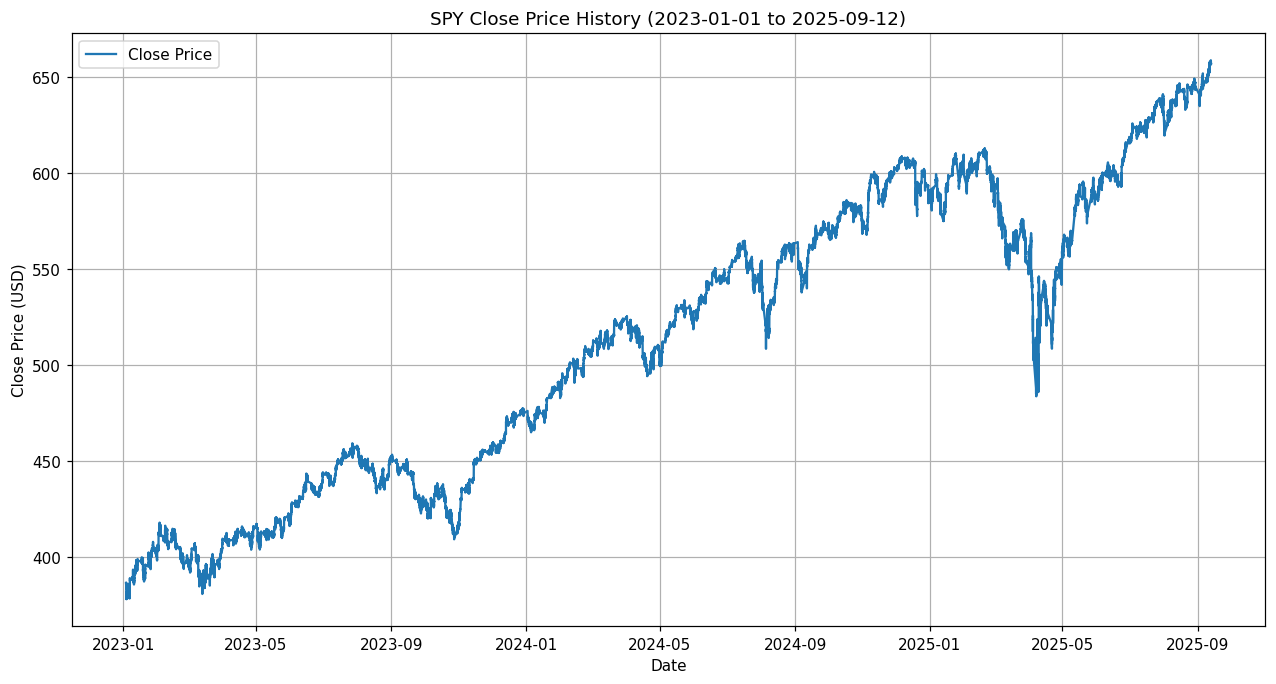

In [83]:
# --- Fetch the Data ---
try:

    stock_data = fetch_data(symbol=SYMBOL, timeframe=timeframe, interval=interval, bars_back=200, start_date=start_date, end_date=end_date)
    stock_data = create_features(stock_data)

    # The .df property returns the data as a pandas DataFrame
    print(f"Successfully fetched {len(stock_data)} data points for {SYMBOL}.")
    print("First 5 rows of the dataset:")
    print(stock_data.head())

    # --- Inspect the Data ---
    print("\nDataset Info:")
    stock_data.info()

    print("\nDataset Description:")
    print(stock_data.describe())

    # --- Plot the Closing Price ---
    plt.figure(figsize=(14, 7))
    plt.plot(stock_data['close'], label='Close Price')
    plt.title(f'{SYMBOL} Close Price History ({start_date} to {end_date})')
    plt.xlabel('Date')
    plt.ylabel('Close Price (USD)')
    plt.legend()
    plt.grid(True)
    plt.show()

except Exception as e:
    print(f"An error occurred while fetching data: {e}")
    print("Please ensure your API keys are correct and have the necessary permissions.")


<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Save the Data to a CSV file
</div>

In [84]:
# --- Save the Data to a CSV file ---

if 'stock_data' in locals() and not stock_data.empty:
    csv_file_path = f'{SYMBOL}_stock_data_{interval}{timeframe}_{start_date}_to_{end_date}.csv'
    stock_data.to_csv(csv_file_path)
    print(f"\nData saved to {csv_file_path}")


Data saved to SPY_stock_data_5minute_2023-01-01_to_2025-09-12.csv


<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Load Data from CSV file
</div>

In [85]:
# Load stock_data from a CSV file (update path if necessary)
csv_file_path = './SPY_stock_data_5minute_2023-01-01_to_2025-09-12.csv'  # <-- change if your file is elsewhere

# Read CSV
stock_data = pd.read_csv(csv_file_path)

# If there's a 'timestamp' column, use it as the DatetimeIndex
if 'timestamp' in stock_data.columns:
    stock_data['timestamp'] = pd.to_datetime(stock_data['timestamp'], errors='coerce')
    stock_data.set_index('timestamp', inplace=True)
# Handle common unnamed index written by to_csv
elif 'Unnamed: 0' in stock_data.columns:
    try:
        stock_data['Unnamed: 0'] = pd.to_datetime(stock_data['Unnamed: 0'], errors='coerce')
        stock_data.set_index('Unnamed: 0', inplace=True)
    except Exception:
        pass
else:
    # Try to convert the existing index to datetime if possible
    try:
        stock_data.index = pd.to_datetime(stock_data.index, errors='coerce')
    except Exception:
        pass

# Quick checks
print(f"Loaded '{csv_file_path}' -> shape: {stock_data.shape}")
print("Index dtype:", stock_data.index.dtype)
stock_data.head()

Loaded './SPY_stock_data_5minute_2023-01-01_to_2025-09-12.csv' -> shape: (126903, 29)
Index dtype: datetime64[ns, UTC]


,close,high,low,trade_count,open,volume,vwap,trade_date,trade_time,momentum_5,...,close_at_4pm,SMA_6,SMA_20,RSI,MACD_6_20_9,MACD_SIGNAL_6_20_9,MACD_HIST_6_20_9,Bollinger_High,Bollinger_Low,Volume_SMA_5
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-01-03 09:00:00+00:00,386.51,386.54,384.00,289,384.00,26198,385.969810,2023-01-03,09:00:00,0.0,...,381.61,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
2023-01-03 09:05:00+00:00,385.96,386.53,385.91,182,386.50,50073,386.063871,2023-01-03,09:05:00,0.0,...,381.61,0.0,0.0,0.0,-0.104762,-0.020952,-0.083810,0.0,0.0,0.0
2023-01-03 09:10:00+00:00,386.51,386.51,386.13,70,386.18,7497,386.308841,2023-01-03,09:10:00,0.0,...,381.61,0.0,0.0,0.0,-0.064853,-0.029732,-0.035120,0.0,0.0,0.0
2023-01-03 09:15:00+00:00,386.28,386.79,386.28,106,386.54,8990,386.608430,2023-01-03,09:15:00,0.0,...,381.61,0.0,0.0,0.0,-0.081106,-0.040007,-0.041099,0.0,0.0,0.0
2023-01-03 09:20:00+00:00,386.70,386.70,386.48,40,386.48,3736,386.571053,2023-01-03,09:20:00,0.0,...,381.61,0.0,0.0,0.0,-0.009402,-0.033886,0.024484,0.0,0.0,19298.8


<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Exploratory Data Analysis
</div>

In [86]:
stock_data.head()

,close,high,low,trade_count,open,volume,vwap,trade_date,trade_time,momentum_5,...,close_at_4pm,SMA_6,SMA_20,RSI,MACD_6_20_9,MACD_SIGNAL_6_20_9,MACD_HIST_6_20_9,Bollinger_High,Bollinger_Low,Volume_SMA_5
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-01-03 09:00:00+00:00,386.51,386.54,384.00,289,384.00,26198,385.969810,2023-01-03,09:00:00,0.0,...,381.61,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
2023-01-03 09:05:00+00:00,385.96,386.53,385.91,182,386.50,50073,386.063871,2023-01-03,09:05:00,0.0,...,381.61,0.0,0.0,0.0,-0.104762,-0.020952,-0.083810,0.0,0.0,0.0
2023-01-03 09:10:00+00:00,386.51,386.51,386.13,70,386.18,7497,386.308841,2023-01-03,09:10:00,0.0,...,381.61,0.0,0.0,0.0,-0.064853,-0.029732,-0.035120,0.0,0.0,0.0
2023-01-03 09:15:00+00:00,386.28,386.79,386.28,106,386.54,8990,386.608430,2023-01-03,09:15:00,0.0,...,381.61,0.0,0.0,0.0,-0.081106,-0.040007,-0.041099,0.0,0.0,0.0
2023-01-03 09:20:00+00:00,386.70,386.70,386.48,40,386.48,3736,386.571053,2023-01-03,09:20:00,0.0,...,381.61,0.0,0.0,0.0,-0.009402,-0.033886,0.024484,0.0,0.0,19298.8


In [87]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 126903 entries, 2023-01-03 09:00:00+00:00 to 2025-09-12 23:55:00+00:00
Data columns (total 29 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   close               126903 non-null  float64
 1   high                126903 non-null  float64
 2   low                 126903 non-null  float64
 3   trade_count         126903 non-null  int64  
 4   open                126903 non-null  float64
 5   volume              126903 non-null  int64  
 6   vwap                126903 non-null  float64
 7   trade_date          126903 non-null  object 
 8   trade_time          126903 non-null  object 
 9   momentum_5          126903 non-null  float64
 10  momentum_10         126903 non-null  float64
 11  stddev_10           126903 non-null  float64
 12  relative_volume_30  126903 non-null  float64
 13  minutes_since_open  126903 non-null  int64  
 14  bar_num             126903 non-null  i

In [88]:
print(stock_data.describe())

               close           high            low    trade_count  \
count  126903.000000  126903.000000  126903.000000  126903.000000   
mean      513.485421     513.662947     513.298710    3035.585250   
std        76.265662      76.275742      76.252519    4754.789851   
min       378.120000     378.330000     377.831000       1.000000   
25%       440.667250     440.790000     440.512500      61.000000   
50%       520.330000     520.505000     520.115000     361.000000   
75%       581.645050     581.864950     581.390000    4853.000000   
max       658.990000     659.110000     658.790000  119279.000000   

                open        volume           vwap     momentum_5  \
count  126903.000000  1.269030e+05  126903.000000  126903.000000   
mean      513.484482  3.701304e+05     513.482785       0.010673   
std        76.265494  7.216138e+05      76.264769       0.801196   
min       378.110000  1.000000e+02     378.209582     -19.730000   
25%       440.655000  4.663500e+03    

Shape: (126903, 29)

Missing values per column:
 close                 0
high                  0
low                   0
trade_count           0
open                  0
volume                0
vwap                  0
trade_date            0
trade_time            0
momentum_5            0
momentum_10           0
stddev_10             0
relative_volume_30    0
minutes_since_open    0
bar_num               0
high_since_open       0
low_since_open        0
cumulative_volume     0
open_at_930am         0
close_at_4pm          0
SMA_6                 0
SMA_20                0
RSI                   0
MACD_6_20_9           0
MACD_SIGNAL_6_20_9    0
MACD_HIST_6_20_9      0
Bollinger_High        0
Bollinger_Low         0
Volume_SMA_5          0
dtype: int64

Descriptive statistics (selected columns):
                close        volume          SMA_6         SMA_20  \
count  126903.000000  1.269030e+05  126903.000000  126903.000000   
mean      513.485421  3.701304e+05     513.464861     513.407

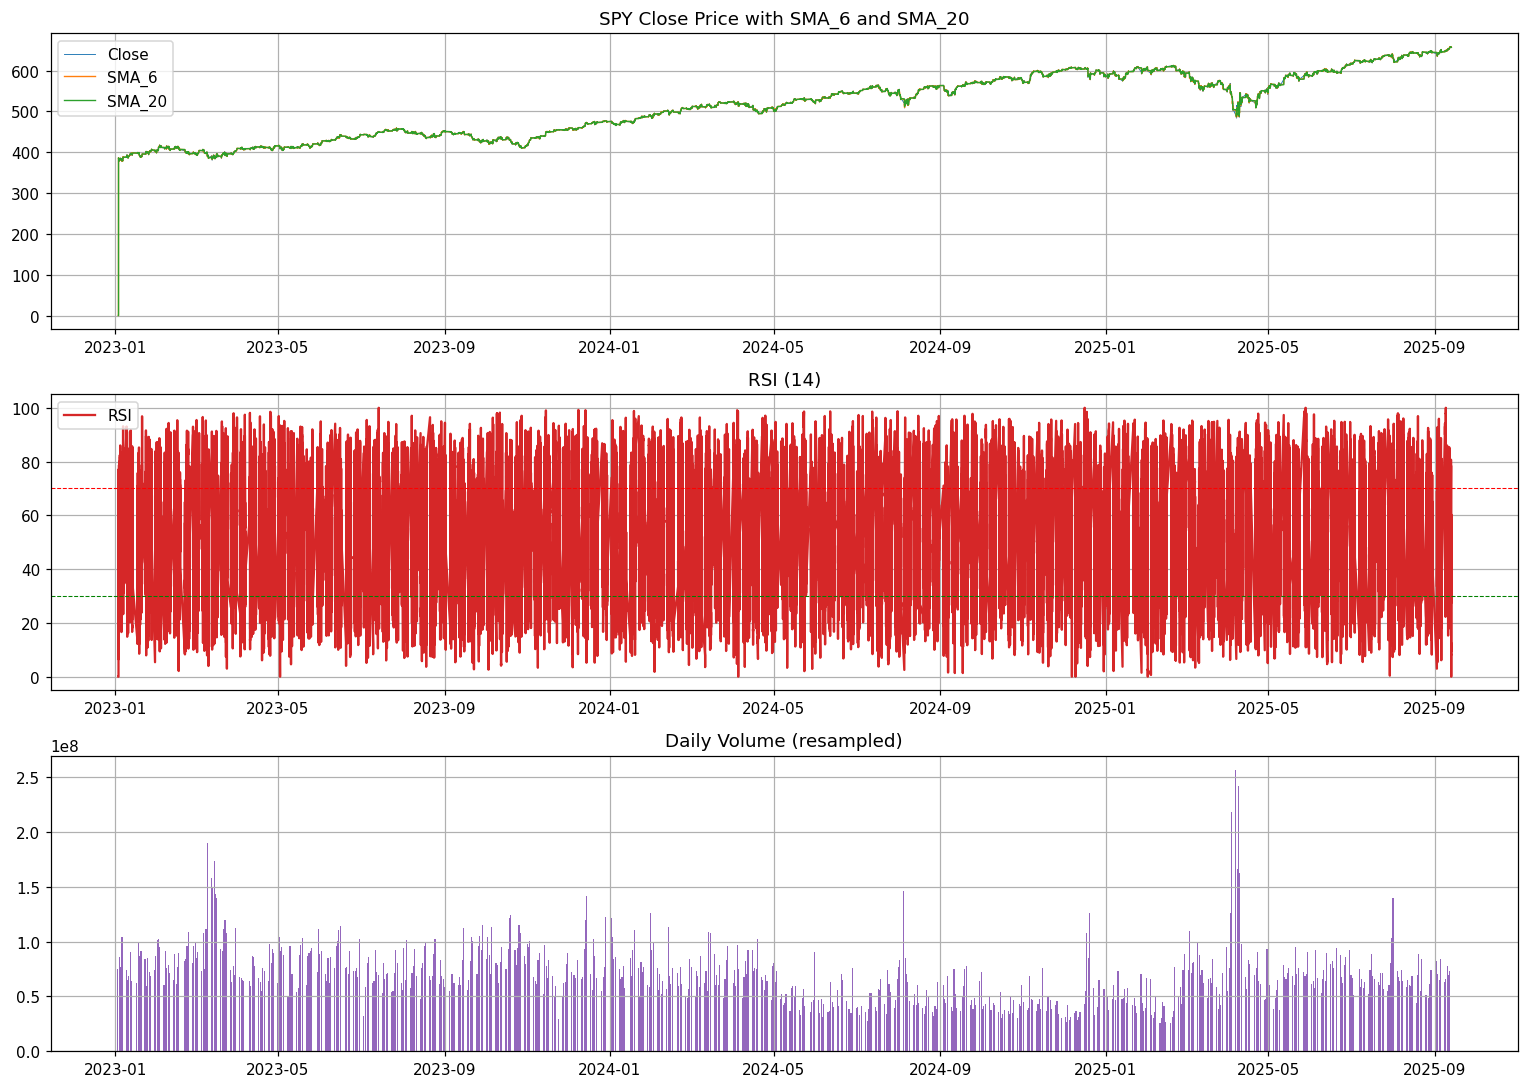

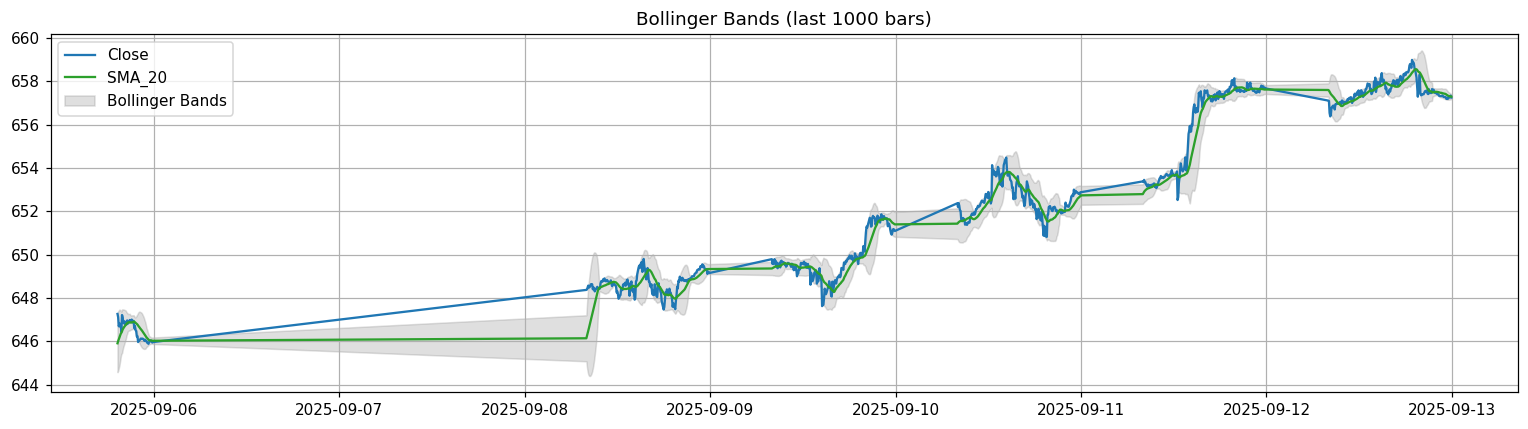

C:\Users\Afiat_Trading\AppData\Local\Temp\ipykernel_27492\2241126096.py:75: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\Afiat_Trading\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


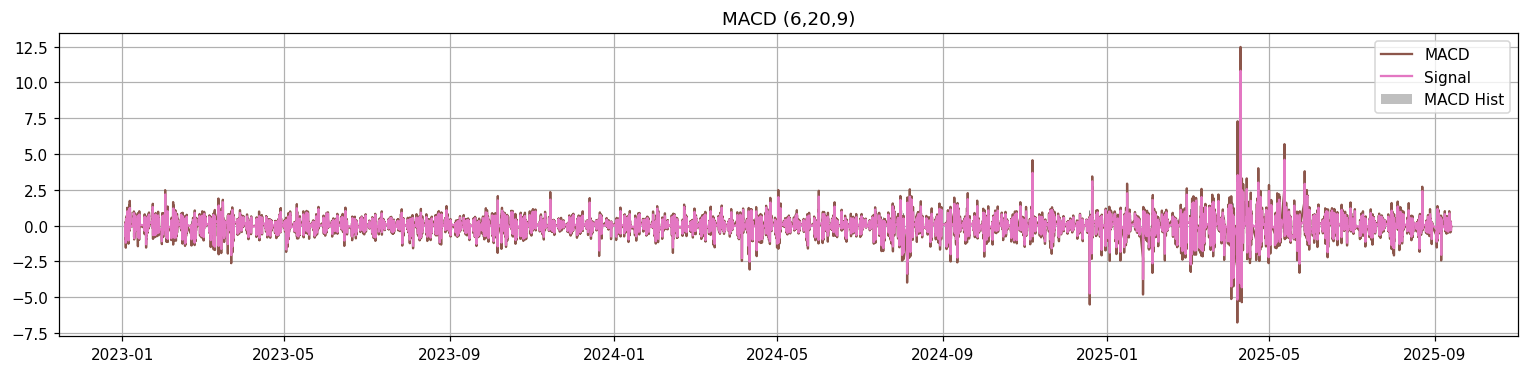

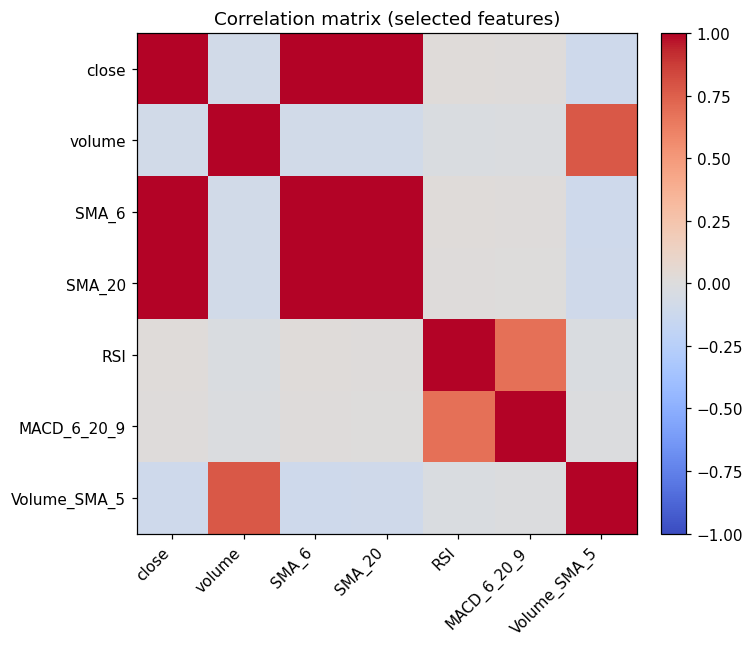

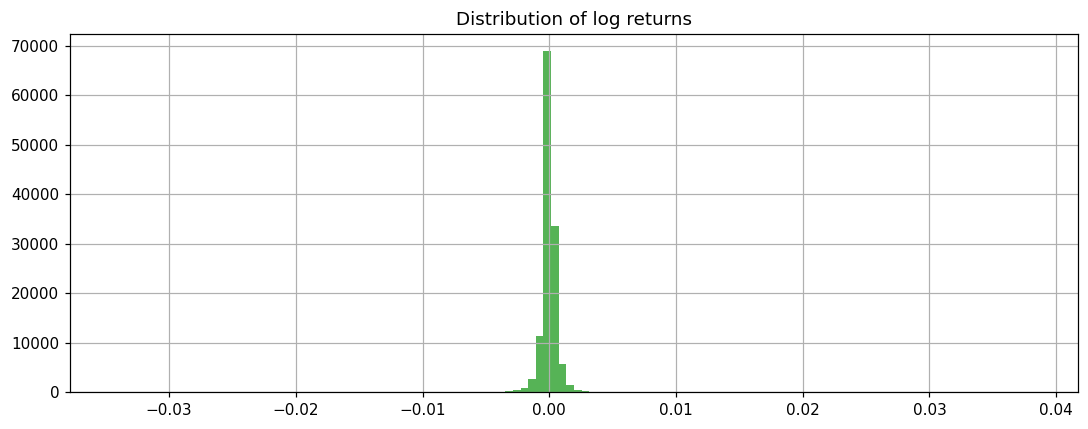

In [89]:
# EDA cell (index 23)
# Uses existing variables/imports: stock_data, SYMBOL, pandas (pd), numpy (np), matplotlib.pyplot (plt)

df = stock_data.copy()

# Basic summaries
print("Shape:", df.shape)
print("\nMissing values per column:\n", df.isna().sum())
print("\nDescriptive statistics (selected columns):\n", df[['close', 'volume', 'SMA_6', 'SMA_20', 'RSI']].describe())

# Engineering simple EDA columns
df['log_return'] = np.log(df['close']).diff()

# Daily aggregations for plotting
daily_close = df['close'].resample('1D').last()
daily_volume = df['volume'].resample('1D').sum()

# Correlation for selected features
features = ['close', 'volume', 'SMA_6', 'SMA_20', 'RSI', 'MACD_6_20_9', 'Volume_SMA_5']
corr = df[features].corr()
print("\nCorrelation matrix (selected features):\n", corr)

# ---- Plots ----
plt.rcParams.update({'figure.dpi': 110})

# 1) Close price with SMAs, RSI and daily volume (stacked)
plt.figure(figsize=(14, 10))

ax1 = plt.subplot(3, 1, 1)
ax1.plot(df.index, df['close'], label='Close', color='C0', linewidth=0.6)
ax1.plot(df.index, df['SMA_6'], label='SMA_6', color='C1', linewidth=0.9)
ax1.plot(df.index, df['SMA_20'], label='SMA_20', color='C2', linewidth=0.9)
ax1.set_title(f"{SYMBOL} Close Price with SMA_6 and SMA_20")
ax1.legend(loc='best')
ax1.grid(True)

ax2 = plt.subplot(3, 1, 2, sharex=ax1)
ax2.plot(df.index, df['RSI'], color='C3', label='RSI')
ax2.axhline(70, color='red', linestyle='--', linewidth=0.7)
ax2.axhline(30, color='green', linestyle='--', linewidth=0.7)
ax2.set_title("RSI (14)")
ax2.legend(loc='best')
ax2.grid(True)

ax3 = plt.subplot(3, 1, 3, sharex=ax1)
ax3.bar(daily_volume.index, daily_volume.values, color='C4', width=0.8)
ax3.set_title("Daily Volume (resampled)")
ax3.grid(True)

plt.tight_layout()
plt.show()

# 2) Bollinger Bands zoom (last N bars)
window = 1000
sub = df[-window:]
plt.figure(figsize=(14, 4))
plt.plot(sub.index, sub['close'], label='Close', color='C0')
plt.plot(sub.index, sub['SMA_20'], label='SMA_20', color='C2')
plt.fill_between(sub.index, sub['Bollinger_Low'], sub['Bollinger_High'],
                 color='grey', alpha=0.25, label='Bollinger Bands')
plt.title(f"Bollinger Bands (last {min(window, len(df))} bars)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3) MACD and histogram
plt.figure(figsize=(14, 3.5))
plt.plot(df.index, df['MACD_6_20_9'], label='MACD', color='C5')
plt.plot(df.index, df['MACD_SIGNAL_6_20_9'], label='Signal', color='C6')
plt.bar(df.index, df['MACD_HIST_6_20_9'], label='MACD Hist', color='gray', alpha=0.5)
plt.title("MACD (6,20,9)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 4) Correlation heatmap (selected features) using matplotlib
plt.figure(figsize=(7, 6))
im = plt.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(features)), features, rotation=45, ha='right')
plt.yticks(range(len(features)), features)
plt.title("Correlation matrix (selected features)")
plt.tight_layout()
plt.show()

# 5) Distribution of log returns
plt.figure(figsize=(10, 4))
vals = df['log_return'].dropna()
plt.hist(vals, bins=120, color='C2', alpha=0.8)
plt.title("Distribution of log returns")
plt.grid(True)
plt.tight_layout()
plt.show()

<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Prepare the Data
</div>

1. Load & Preprocess the Data

In [90]:
def load_and_preprocess_data(csv_path):
    """Load and preprocess the SPY bar data"""
    print("Loading and preprocessing data...")

    # Load the CSV data directly
    df = pd.read_csv(csv_path)

    # Convert trade_date to datetime
    df["trade_date"] = pd.to_datetime(df["trade_date"])

    # Convert trade_time to datetime.time objects consistently
    if "trade_time" in df.columns:
        if isinstance(df["trade_time"].iloc[0], str):
            # Convert string time to datetime.time objects
            df["trade_time"] = pd.to_datetime(df["trade_time"], errors='coerce').dt.time

    # Filter incomplete rows
    df = df[df["close"].notnull()].copy()

    # Sort by timestamp
    

    df = df.sort_values("timestamp")
    
    # Fill or drop missing values
    df["momentum_5"] = df["momentum_5"].fillna(0)
    df["momentum_10"] = df["momentum_10"].fillna(0)
    df["stddev_10"] = df["stddev_10"].bfill().fillna(0)
    df["relative_volume_30"] = df["relative_volume_30"].bfill().fillna(0)
    df["SMA_6"] = df["SMA_6"].bfill().fillna(0)
    df["SMA_20"] = df["SMA_20"].bfill().fillna(0)
    df["RSI"] = df["RSI"].bfill().fillna(0)
    df["MACD_6_20_9"] = df["MACD_6_20_9"].bfill().fillna(0)
    df["MACD_SIGNAL_6_20_9"] = df["MACD_SIGNAL_6_20_9"].bfill().fillna(0)
    df["MACD_HIST_6_20_9"] = df["MACD_HIST_6_20_9"].bfill().fillna(0)

    # Forward fill open_at_930am per day
    df["open_at_930am"] = df.groupby("trade_date")["open_at_930am"].transform(lambda x: x.ffill().bfill())

    # Fill minutes_since_open with -1 to indicate non-market hours
    df["minutes_since_open"] = df["minutes_since_open"].fillna(-1)

    print(f"Preprocessed data shape: {df.shape}")
    print(f"Date range: {df['trade_date'].min()} to {df['trade_date'].max()}")

    return df

In [113]:
def load_and_preprocess_data_df(df):
    """Load and preprocess the SPY bar data"""
    print("Loading and preprocessing data...")

    # Convert trade_date to datetime
    df["trade_date"] = pd.to_datetime(df["trade_date"])

    # Convert trade_time to datetime.time objects consistently
    if "trade_time" in df.columns:
        if isinstance(df["trade_time"].iloc[0], str):
            # Convert string time to datetime.time objects
            df["trade_time"] = pd.to_datetime(df["trade_time"], errors='coerce').dt.time

    # Filter incomplete rows
    df = df[df["close"].notnull()].copy()

    # Sort by timestamp
    

    df = df.sort_values("timestamp")
    
    # Fill or drop missing values
    df["momentum_5"] = df["momentum_5"].fillna(0)
    df["momentum_10"] = df["momentum_10"].fillna(0)
    df["stddev_10"] = df["stddev_10"].bfill().fillna(0)
    df["relative_volume_30"] = df["relative_volume_30"].bfill().fillna(0)
    df["SMA_6"] = df["SMA_6"].bfill().fillna(0)
    df["SMA_20"] = df["SMA_20"].bfill().fillna(0)
    df["RSI"] = df["RSI"].bfill().fillna(0)
    df["MACD_6_20_9"] = df["MACD_6_20_9"].bfill().fillna(0)
    df["MACD_SIGNAL_6_20_9"] = df["MACD_SIGNAL_6_20_9"].bfill().fillna(0)
    df["MACD_HIST_6_20_9"] = df["MACD_HIST_6_20_9"].bfill().fillna(0)

    # Forward fill open_at_930am per day
    df["open_at_930am"] = df.groupby("trade_date")["open_at_930am"].transform(lambda x: x.ffill().bfill())

    # Fill minutes_since_open with -1 to indicate non-market hours
    df["minutes_since_open"] = df["minutes_since_open"].fillna(-1)

    print(f"Preprocessed data shape: {df.shape}")
    print(f"Date range: {df['trade_date'].min()} to {df['trade_date'].max()}")

    return df

In [91]:
stock_data_preprocessed = load_and_preprocess_data(csv_file_path)
stock_data_preprocessed.head()

Loading and preprocessing data...
Preprocessed data shape: (126903, 30)
Date range: 2023-01-03 00:00:00 to 2025-09-12 00:00:00


C:\Users\Afiat_Trading\AppData\Local\Temp\ipykernel_27492\3612006824.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["trade_time"] = pd.to_datetime(df["trade_time"], errors='coerce').dt.time


,timestamp,close,high,low,trade_count,open,volume,vwap,trade_date,trade_time,...,close_at_4pm,SMA_6,SMA_20,RSI,MACD_6_20_9,MACD_SIGNAL_6_20_9,MACD_HIST_6_20_9,Bollinger_High,Bollinger_Low,Volume_SMA_5
0,2023-01-03 09:00:00+00:00,386.51,386.54,384.00,289,384.00,26198,385.969810,2023-01-03,09:00:00,...,381.61,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
1,2023-01-03 09:05:00+00:00,385.96,386.53,385.91,182,386.50,50073,386.063871,2023-01-03,09:05:00,...,381.61,0.0,0.0,0.0,-0.104762,-0.020952,-0.083810,0.0,0.0,0.0
2,2023-01-03 09:10:00+00:00,386.51,386.51,386.13,70,386.18,7497,386.308841,2023-01-03,09:10:00,...,381.61,0.0,0.0,0.0,-0.064853,-0.029732,-0.035120,0.0,0.0,0.0
3,2023-01-03 09:15:00+00:00,386.28,386.79,386.28,106,386.54,8990,386.608430,2023-01-03,09:15:00,...,381.61,0.0,0.0,0.0,-0.081106,-0.040007,-0.041099,0.0,0.0,0.0
4,2023-01-03 09:20:00+00:00,386.70,386.70,386.48,40,386.48,3736,386.571053,2023-01-03,09:20:00,...,381.61,0.0,0.0,0.0,-0.009402,-0.033886,0.024484,0.0,0.0,19298.8


2. Calculate the Reference Price

In [92]:
def calculate_reference_prices(df, reference_hour=11, reference_minute=0):
    """Calculate reference price at the specified time for each trading day"""
    print(f"Calculating reference prices at {reference_hour}:{reference_minute}...")

    # Make a copy to avoid SettingWithCopyWarning
    df = df.copy()

    # Ensure trade_time is properly formatted
    if "trade_time" in df.columns and len(df) > 0:
        if isinstance(df["trade_time"].iloc[0], str):
            try:
                df["trade_time"] = pd.to_datetime(df["trade_time"], errors='coerce').dt.time
            except Exception as e:
                print(f"Warning: Could not convert trade_time to datetime: {e}")
                # Create a fallback time column for comparison
                df["time_for_comparison"] = df["trade_time"]

    unique_dates = df['trade_date'].unique()
    print(f"Found {len(unique_dates)} unique trading days")

    # Create a reference time object for comparison
    from datetime import time
    reference_time = time(reference_hour, reference_minute)

    # Prepare a list to hold results
    reference_price_data = []

    # For each trading day, find the price at the reference time
    for date in unique_dates:
        day_data = df[df['trade_date'] == date].copy()

        if len(day_data) == 0:
            print(f"No data for date {date}")
            continue

        try:
            # Determine which column to use for time comparison
            time_column = "trade_time"
            if "time_for_comparison" in day_data.columns:
                time_column = "time_for_comparison"

            # Debug output
            #print(f"Processing date {date}, time column: {time_column}, data shape: {day_data.shape}")

            # Try to find bars before or at reference time
            # Handle different time formats
            if isinstance(day_data[time_column].iloc[0], time):
                # It's already a time object
                bars_before_reference = day_data[day_data[time_column] <= reference_time]
            elif isinstance(day_data[time_column].iloc[0], str):
                # It's a string, try string comparison
                reference_str = f"{reference_hour:02d}:{reference_minute:02d}:00"
                bars_before_reference = day_data[day_data[time_column] <= reference_str]
            else:
                # Use all data as fallback
                print(f"Warning: Unrecognized time format for {date}, using all data")
                bars_before_reference = day_data

            if len(bars_before_reference) > 0:
                # Get the bar closest to reference time (the last one before reference time)
                # Sort by timestamp if available
                if "bar_ts" in bars_before_reference.columns:
                    last_bar = bars_before_reference.sort_values('bar_ts', ascending=False).iloc[0]
                else:
                    last_bar = bars_before_reference.sort_values(time_column, ascending=False).iloc[0]

                reference_price = last_bar['close']

                # Add to results
                reference_price_data.append({
                    'trade_date': date,
                    'reference_price': reference_price
                })
                #print(f"Found reference price for {date}: {reference_price}")
            else:
                # If no bars before reference time, use first bar of the day
                if "bar_ts" in day_data.columns:
                    first_bar = day_data.sort_values('bar_ts').iloc[0]
                else:
                    first_bar = day_data.sort_values(time_column).iloc[0]

                reference_price_data.append({
                    'trade_date': date,
                    'reference_price': first_bar['close']
                })
                print(f"No bars before reference time for {date}, using first bar price: {first_bar['close']}")

        except Exception as e:
            print(f"Error processing date {date}: {e}")
            # Try to get any price for this day as fallback
            try:
                reference_price_data.append({
                    'trade_date': date,
                    'reference_price': day_data.iloc[0]['close']
                })
                print(f"Using fallback price for {date}: {day_data.iloc[0]['close']}")
            except:
                print(f"Could not get any price for {date}")

    # Create a DataFrame from the results
    reference_price_df = pd.DataFrame(reference_price_data)
    print(f"Generated reference prices for {len(reference_price_df)} trading days")

    # Debug: Print the reference price dataframe
    print("\nSample of reference prices dataframe:")
    print(reference_price_df.head())

    # Merge back with original DataFrame
    df_with_reference = pd.merge(df, reference_price_df, on='trade_date', how='left')

    # Calculate price change from reference time to close
    if 'close_at_4pm' in df_with_reference.columns:
        df_with_reference['price_change_reference_to_close'] = df_with_reference['close_at_4pm'] - df_with_reference['reference_price']

        print(f"Null reference prices: {df_with_reference['reference_price'].isna().sum()} out of {len(df_with_reference)}")
        print(f"Null close_at_4pm: {df_with_reference['close_at_4pm'].isna().sum()} out of {len(df_with_reference)}")
        print(f"Null price_change: {df_with_reference['price_change_reference_to_close'].isna().sum()} out of {len(df_with_reference)}")
    else:
        print("WARNING: 'close_at_4pm' column not found! Cannot calculate price change.")

    # Create a sample to verify data
    if 'close_at_4pm' in df_with_reference.columns:
        sample = df_with_reference[['trade_date', 'reference_price', 'close_at_4pm', 'price_change_reference_to_close']
                             ].drop_duplicates('trade_date').head(5)
        print("\nSample reference and close prices:")
        print(sample)
    else:
        sample = df_with_reference[['trade_date', 'reference_price']].drop_duplicates('trade_date').head(5)
        print("\nSample reference prices (close_at_4pm not available):")
        print(sample)

    # Debug info about columns
    print("\nColumns in result dataframe:")
    print(df_with_reference.columns.tolist())

    return df_with_reference

In [93]:
# Calculate reference prices at 11am
stock_data_preprocessed_with_reference = calculate_reference_prices(stock_data_preprocessed, reference_hour=12, reference_minute=0)

# Add a debug step to check the columns
print("\nChecking dataframe columns after calculate_reference_prices:")
print(stock_data_preprocessed_with_reference.columns.tolist())
print("\nSample of reference_price column:")
if 'reference_price' in stock_data_preprocessed_with_reference.columns:
    print(stock_data_preprocessed_with_reference[['trade_date', 'reference_price']].drop_duplicates('trade_date').head())
else:
    print("WARNING: 'reference_price' column is missing!")

Calculating reference prices at 12:0...
Found 715 unique trading days
Generated reference prices for 715 trading days

Sample of reference prices dataframe:
  trade_date  reference_price
0 2023-01-03           383.61
1 2023-01-04           382.17
2 2023-01-05           384.14
3 2023-01-06           379.48
4 2023-01-09           389.62
Null reference prices: 0 out of 126903
Null close_at_4pm: 0 out of 126903
Null price_change: 0 out of 126903

Sample reference and close prices:
    trade_date  reference_price  close_at_4pm  price_change_reference_to_close
0   2023-01-03           383.61      381.6100                          -2.0000
179 2023-01-04           382.17      382.5120                           0.3420
370 2023-01-05           384.14      379.5809                          -4.5591
562 2023-01-06           379.48      385.5900                           6.1100
742 2023-01-09           389.62      393.1099                           3.4899

Columns in result dataframe:
['timestamp', 

<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Build the LSTM Model
</div>

1. Build LSTM Sequence

In [94]:
def build_lstm_sequences(df, features, lookback_days=7, cutoff_time=time(12, 0)):
    """Build input sequences for the LSTM model"""
    print(f"\nBuilding LSTM sequences with {lookback_days} days lookback...")

    # Ensure trade_date is in datetime format
    df = df.copy()
    df["trade_date"] = pd.to_datetime(df["trade_date"])

    # Make sure trade_time is properly handled
    if "trade_time" in df.columns and len(df) > 0:
        if isinstance(df["trade_time"].iloc[0], str):
            try:
                df["trade_time"] = pd.to_datetime(df["trade_time"], errors='coerce').dt.time
            except Exception as e:
                print(f"Warning: Could not convert trade_time to datetime: {e}")
                # Create a fallback column
                df["time_for_comparison"] = df["trade_time"]

    # Debug output
    print("\nChecking for reference_price column in dataframe:")
    print(f"Columns available: {df.columns.tolist()}")
    if 'reference_price' in df.columns:
        print(f"Reference price column exists, sample values: {df['reference_price'].head()}")
    else:
        print("WARNING: reference_price column is MISSING!")
        return np.array([]), np.array([]), [], np.array([])

    # Print feature list with dtypes
    print("\nFeature list:")
    for feature in features:
        if feature in df.columns:
            print(f"  {feature}: {df[feature].dtype}")
        else:
            print(f"  {feature}: NOT FOUND")

    # Get unique dates sorted chronologically
    trade_dates = sorted(df["trade_date"].unique())
    print(f"Total trading days: {len(trade_dates)}")

    # Define sequence parameters
    expected_bars_per_day = 390
    current_day_bars_cutoff = 30
    sequence_length = lookback_days * expected_bars_per_day + current_day_bars_cutoff

    # Prepare containers for sequences
    X, y, date_labels, reference_prices = [], [], [], []

    # Loop through dates to build sequences
    sequences_built = 0
    sequences_skipped = 0

    for i in range(lookback_days, len(trade_dates)):
        past_dates = trade_dates[i - lookback_days:i]
        target_date = trade_dates[i]

        try:
            # Get past days' data
            past_data = df[df["trade_date"].isin(past_dates)]
            if len(past_data) == 0:
                print(f"No past data for dates {past_dates}")
                sequences_skipped += 1
                continue

            # Get current day's data up to cutoff time
            day_data = df[df["trade_date"] == target_date]

            if len(day_data) == 0:
                print(f"No data for target date {target_date}")
                sequences_skipped += 1
                continue

            # Determine which column to use for time comparison
            time_column = "trade_time"
            if "time_for_comparison" in day_data.columns:
                time_column = "time_for_comparison"

            # Get data up to cutoff time
            try:
                if isinstance(day_data[time_column].iloc[0], time):
                    # It's already a time object
                    current_data = day_data[day_data[time_column] <= cutoff_time]
                elif isinstance(day_data[time_column].iloc[0], str):
                    # It's a string, try string comparison
                    cutoff_str = f"{cutoff_time.hour:02d}:{cutoff_time.minute:02d}:00"
                    current_data = day_data[day_data[time_column] <= cutoff_str]
                else:
                    # Use first 30 minutes as fallback
                    print(f"Warning: Unrecognized time format for {target_date}, using first 30 rows")
                    current_data = day_data.head(30)
            except Exception as e:
                print(f"Error filtering by time for {target_date}: {e}")
                current_data = day_data.head(30)  # Fallback

            if len(current_data) == 0:
                print(f"No current data up to cutoff time for {target_date}")
                sequences_skipped += 1
                continue

            # Get target values for this date
            target_data = df[(df["trade_date"] == target_date) &
                            (df["reference_price"].notna())]

            if 'close_at_4pm' in df.columns:
                target_data = target_data[target_data["close_at_4pm"].notna()]

            if len(target_data) == 0:
                print(f"No target data for {target_date}")
                sequences_skipped += 1
                continue

            # Get reference price and close price for this date
            reference_price = target_data["reference_price"].iloc[0]

            # Calculate price change
            if 'close_at_4pm' in target_data.columns:
                close_price = target_data["close_at_4pm"].iloc[0]
                price_change = close_price - reference_price
            else:
                # If close_at_4pm is not available, use last available close of the day
                day_end_data = df[df["trade_date"] == target_date].sort_values("bar_ts", ascending=False)
                if len(day_end_data) > 0:
                    close_price = day_end_data.iloc[0]["close"]
                    price_change = close_price - reference_price
                else:
                    print(f"No day end data for {target_date}")
                    sequences_skipped += 1
                    continue

            # Combine past and current data
            sequence_df = pd.concat([past_data, current_data])

            # Check for missing features
            missing_features = [f for f in features if f not in sequence_df.columns]
            if missing_features:
                print(f"Missing features for date {target_date}: {missing_features}")
                sequences_skipped += 1
                continue

            # Extract feature values
            features_only = sequence_df[features].values

            # Handle sequence length (pad or truncate)
            if len(features_only) < sequence_length:
                pad_len = sequence_length - len(features_only)
                padded = np.pad(features_only, ((pad_len, 0), (0, 0)), mode="constant", constant_values=0)
            elif len(features_only) > sequence_length:
                padded = features_only[-sequence_length:]
            else:
                padded = features_only

            # Store the sequence
            X.append(padded)
            y.append(price_change)
            date_labels.append(target_date)
            reference_prices.append(reference_price)

            sequences_built += 1
            if sequences_built % 50 == 0:
                print(f"Built {sequences_built} sequences so far...")

        except Exception as e:
            print(f"Error building sequence for date {target_date}: {e}")
            import traceback
            traceback.print_exc()
            sequences_skipped += 1

    print(f"Sequences built: {sequences_built}, Sequences skipped: {sequences_skipped}")

    if sequences_built == 0:
        print("WARNING: No valid sequences could be built!")
        return np.array([]), np.array([]), [], np.array([])

    return np.array(X), np.array(y), date_labels, np.array(reference_prices)


2. Select Features for the LSTM Model

In [95]:
print(stock_data_preprocessed_with_reference.columns)

Index(['timestamp', 'close', 'high', 'low', 'trade_count', 'open', 'volume',
       'vwap', 'trade_date', 'trade_time', 'momentum_5', 'momentum_10',
       'stddev_10', 'relative_volume_30', 'minutes_since_open', 'bar_num',
       'high_since_open', 'low_since_open', 'cumulative_volume',
       'open_at_930am', 'close_at_4pm', 'SMA_6', 'SMA_20', 'RSI',
       'MACD_6_20_9', 'MACD_SIGNAL_6_20_9', 'MACD_HIST_6_20_9',
       'Bollinger_High', 'Bollinger_Low', 'Volume_SMA_5', 'reference_price',
       'price_change_reference_to_close'],
      dtype='object')


3. Build the Sequence

In [96]:
'''
features = [
    "open", "high", "low", "close", "volume",
    "momentum_5", "momentum_10", "stddev_10",
    "minutes_since_open", "vwap", "trade_count", 
    "relative_volume_30", 'high_since_open', 'low_since_open', 
    'cumulative_volume', 'open_at_930am', 'close_at_4pm', 
    'SMA_6', 'SMA_20', 'RSI', 'MACD_6_20_9', 
    'MACD_SIGNAL_6_20_9', 'MACD_HIST_6_20_9', 
    'Bollinger_High', 'Bollinger_Low', 'Volume_SMA_5' 
]

'''

# Define features for the model
features = [
    "open", "high", "low", "close", "volume",
    "momentum_5", "momentum_10", "stddev_10",
    "minutes_since_open"
]

#TODO::Why are so many features missing?
#features = [
#    "open", "high", "low", "close", "volume",
#    "vwap", "momentum_5", "momentum_10", "stddev_10",
#    "relative_volume_30", "minutes_since_open",
#    "high_since_open", "low_since_open", "cumulative_volume",
#    "open_at_930am"
#]

# Build sequences - with explicit debugging output
print("\nBuilding sequences with reference to time...")
X, y, dates, reference_prices = build_lstm_sequences(
    stock_data_preprocessed_with_reference,
    features,
    lookback_days=6,
    cutoff_time=time(12, 0)
)

print(f"\nSequence results: X shape: {X.shape if len(X) > 0 else 'Empty'}, len(y): {len(y)}, len(dates): {len(dates)}")


Building sequences with reference to time...

Building LSTM sequences with 6 days lookback...

Checking for reference_price column in dataframe:
Columns available: ['timestamp', 'close', 'high', 'low', 'trade_count', 'open', 'volume', 'vwap', 'trade_date', 'trade_time', 'momentum_5', 'momentum_10', 'stddev_10', 'relative_volume_30', 'minutes_since_open', 'bar_num', 'high_since_open', 'low_since_open', 'cumulative_volume', 'open_at_930am', 'close_at_4pm', 'SMA_6', 'SMA_20', 'RSI', 'MACD_6_20_9', 'MACD_SIGNAL_6_20_9', 'MACD_HIST_6_20_9', 'Bollinger_High', 'Bollinger_Low', 'Volume_SMA_5', 'reference_price', 'price_change_reference_to_close']
Reference price column exists, sample values: 0    383.61
1    383.61
2    383.61
3    383.61
4    383.61
Name: reference_price, dtype: float64

Feature list:
  open: float64
  high: float64
  low: float64
  close: float64
  volume: int64
  momentum_5: float64
  momentum_10: float64
  stddev_10: float64
  minutes_since_open: int64
Total trading days:

4. Split Dataset

In [97]:
# The following functions remain unchanged from your original code
def split_dataset(X, y, dates, noon_prices, train_ratio=0.7, val_ratio=0.15):
    """Split dataset into training, validation, and test sets"""
    if len(X) == 0:
        print("Cannot split an empty dataset!")
        return (np.array([]), np.array([]), np.array([]), [], np.array([]),
                np.array([]), np.array([]), [], np.array([]),
                np.array([]), np.array([]), [], np.array([]))

    print(f"\nSplitting dataset with {len(X)} sequences...")

    # Calculate split indices
    train_size = int(len(X) * train_ratio)
    val_size = int(len(X) * val_ratio)

    # Split data chronologically
    X_train, y_train = X[:train_size], y[:train_size]
    X_val = X[train_size:train_size+val_size]
    y_val = y[train_size:train_size+val_size]
    X_test = X[train_size+val_size:]
    y_test = y[train_size+val_size:]

    # Split dates and noon prices
    train_dates = dates[:train_size]
    val_dates = dates[train_size:train_size+val_size]
    test_dates = dates[train_size+val_size:]

    train_noon_prices = noon_prices[:train_size]
    val_noon_prices = noon_prices[train_size:train_size+val_size]
    test_noon_prices = noon_prices[train_size+val_size:]

    print(f"Training set: {X_train.shape}, Validation set: {X_val.shape}, Test set: {X_test.shape}")

    if len(train_dates) > 0:
        print(f"Train dates: {train_dates[0]} to {train_dates[-1]}")
    if len(test_dates) > 0:
        print(f"Test dates: {test_dates[0]} to {test_dates[-1]}")

    return (X_train, y_train, train_dates, train_noon_prices,
            X_val, y_val, val_dates, val_noon_prices,
            X_test, y_test, test_dates, test_noon_prices)

In [98]:
# Split dataset - note the variable name change from noon_prices to reference_prices
print("\nSplitting dataset...")
(X_train, y_train, train_dates, train_reference_prices,
 X_val, y_val, val_dates, val_reference_prices,
 X_test, y_test, test_dates, test_reference_prices) = split_dataset(
    X, y, dates, reference_prices, train_ratio=0.7, val_ratio=0.15
)


Splitting dataset...

Splitting dataset with 709 sequences...
Training set: (496, 2370, 9), Validation set: (106, 2370, 9), Test set: (107, 2370, 9)
Train dates: 2023-01-11 00:00:00 to 2024-11-27 00:00:00
Test dates: 2025-04-10 00:00:00 to 2025-09-12 00:00:00


5. Scale the Dataset

In [99]:

def scale_data(X_train, y_train, X_val, y_val, X_test, y_test):
    """Scale features and target values"""
    if len(X_train) == 0:
        print("Cannot scale empty datasets!")
        return None, None, np.array([]), np.array([]), np.array([]), np.array([])

    # Get dimensions from training data
    num_samples, timesteps, num_features = X_train.shape
    print(f"Scaling data with shape: {timesteps} timesteps, {num_features} features")

    # Reshape for scaling
    X_train_reshaped = X_train.reshape(-1, num_features)
    X_val_reshaped = X_val.reshape(-1, num_features) if len(X_val) > 0 else np.array([]).reshape(0, num_features)
    X_test_reshaped = X_test.reshape(-1, num_features) if len(X_test) > 0 else np.array([]).reshape(0, num_features)

    # Scale features
    feature_scaler = StandardScaler()
    X_train_scaled = feature_scaler.fit_transform(X_train_reshaped).reshape(X_train.shape)
    X_val_scaled = feature_scaler.transform(X_val_reshaped).reshape(X_val.shape) if len(X_val) > 0 else np.array([])
    X_test_scaled = feature_scaler.transform(X_test_reshaped).reshape(X_test.shape) if len(X_test) > 0 else np.array([])

    # Scale targets
    target_scaler = StandardScaler()
    y_train_scaled = target_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_val_scaled = target_scaler.transform(y_val.reshape(-1, 1)).flatten() if len(y_val) > 0 else np.array([])
    y_test_scaled = target_scaler.transform(y_test.reshape(-1, 1)).flatten() if len(y_test) > 0 else np.array([])

    return feature_scaler, target_scaler, X_train_scaled, y_train_scaled, X_val_scaled, y_val_scaled, X_test_scaled, y_test_scaled


In [100]:
print("\nScaling data...")
feature_scaler, target_scaler, X_train_scaled, y_train_scaled, X_val_scaled, y_val_scaled, X_test_scaled, y_test_scaled = scale_data(
    X_train, y_train, X_val, y_val, X_test, y_test
)



Scaling data...
Scaling data with shape: 2370 timesteps, 9 features


6. Create the LSTM Model

In [101]:
def create_lstm_model(input_shape):
    """Create and compile LSTM model"""
    model = Sequential([
        LSTM(64, input_shape=input_shape, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)  # Output: price change from noon to close
    ])

    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    return model

In [102]:
# Create and train model
print("\nCreating and training model...")
input_shape = (X_train_scaled.shape[1], X_train_scaled.shape[2])
model = create_lstm_model(input_shape)
model.summary()



Creating and training model...


c:\Users\Afiat_Trading\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 2370, 64)       │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2370, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,905 (124.63 KB)

 Trainable params: 31,905 (124.63 KB)

 Non-trainable params: 0 (0.00 B)

<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Train the Model
</div>

1. Train the Model

In [103]:

def train_model(model, X_train_scaled, y_train_scaled, X_val_scaled, y_val_scaled, epochs=50, batch_size=32):
    """Train the LSTM model"""
    # Add callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=0.0001,
            verbose=1
        )
    ]

    # Train the model
    history = model.fit(
        X_train_scaled, y_train_scaled,
        validation_data=(X_val_scaled, y_val_scaled),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )

    return model, history


In [104]:
model, history = train_model(
    model,
    X_train_scaled, y_train_scaled,
    X_val_scaled, y_val_scaled,
    epochs=50,
    batch_size=32
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - loss: 0.8405 - mae: 0.3340 - val_loss: 2.9570 - val_mae: 0.8509 - learning_rate: 0.0010
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - loss: 0.4228 - mae: 0.2799 - val_loss: 1.2466 - val_mae: 0.6692 - learning_rate: 0.0010
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - loss: 0.1207 - mae: 0.1452 - val_loss: 0.2778 - val_mae: 0.2922 - learning_rate: 0.0010
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - loss: 0.0296 - mae: 0.0791 - val_loss: 0.3824 - val_mae: 0.2725 - learning_rate: 0.0010
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - loss: 0.0442 - mae: 0.0781 - val_loss: 0.1139 - val_mae: 0.1677 - learning_rate: 0.0010
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - loss: 0.0342 - mae: 0.0770 - val_loss: 0.1472 - val_mae: 0.1885 - learning_rate: 0.0010
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - loss: 0.0184 - mae: 0.0622 - val_loss: 0.0492 - val_mae: 0.1202 - learning_rate: 0.0010
Epoch 8/50
16/16 ━━━

<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Performance Analysis
</div>

1. Plot Training History

In [105]:

def plot_training_history(history):
    """Plot training and validation loss/metrics"""
    plt.figure(figsize=(12, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    # MAE plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Training MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.title('Mean Absolute Error')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.show()


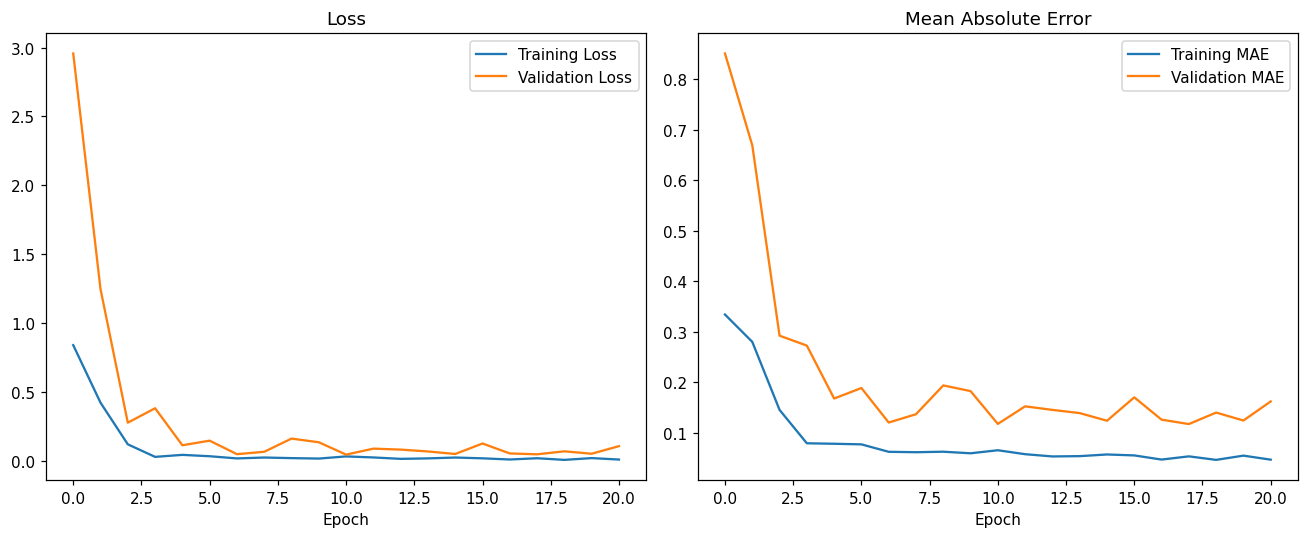

In [106]:
plot_training_history(history)

2. Evaluate the Model

In [107]:
def evaluate_model(model, target_scaler, X_test_scaled, y_test, test_noon_prices):
    """Evaluate model and return metrics and predictions"""
    # Make predictions
    y_pred_scaled = model.predict(X_test_scaled)

    # Inverse transform predictions
    y_pred_changes = target_scaler.inverse_transform(y_pred_scaled).flatten()

    # Calculate 4pm close predictions
    y_pred_close = test_noon_prices + y_pred_changes
    y_test_close = test_noon_prices + y_test

    # Calculate metrics for price changes
    mse_change = np.mean((y_test - y_pred_changes)**2)
    mae_change = np.mean(np.abs(y_test - y_pred_changes))
    rmse_change = np.sqrt(mse_change)

    # Calculate metrics for close prices
    mse_close = np.mean((y_test_close - y_pred_close)**2)
    mae_close = np.mean(np.abs(y_test_close - y_pred_close))
    rmse_close = np.sqrt(mse_close)

    # Calculate directional accuracy
    correct_direction = np.sum((y_test > 0) == (y_pred_changes > 0))
    direction_accuracy = correct_direction / len(y_test) * 100 if len(y_test) > 0 else 0

    # Print metrics
    print("\n=== Model Evaluation ===")
    print(f"Price Change Metrics:")
    print(f"  MSE: {mse_change:.4f}")
    print(f"  MAE: {mae_change:.4f}")
    print(f"  RMSE: {rmse_change:.4f}")

    print(f"\nClose Price Metrics:")
    print(f"  MSE: {mse_close:.4f}")
    print(f"  MAE: {mae_close:.4f}")
    print(f"  RMSE: {rmse_close:.4f}")

    print(f"\nMean Values:")
    print(f"  Mean Predicted Change: {np.mean(y_pred_changes):.4f}")
    print(f"  Mean Actual Change: {np.mean(y_test):.4f}")
    print(f"  Mean Predicted Close: {np.mean(y_pred_close):.4f}")
    print(f"  Mean Actual Close: {np.mean(y_test_close):.4f}")
    print(f"  Average prediction offset: {np.mean(y_test_close - y_pred_close):.4f}")

    print(f"\nDirectional Accuracy: {direction_accuracy:.2f}%")

    return y_pred_changes, y_pred_close, y_test_close

In [108]:
# Evaluate model - note the variable name change
y_pred_changes, y_pred_close, y_test_close = evaluate_model(
    model,
    target_scaler,
    X_test_scaled,
    y_test,
    test_reference_prices  # Using reference_prices instead of noon_prices
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 433ms/step

=== Model Evaluation ===
Price Change Metrics:
  MSE: 23.0793
  MAE: 3.8271
  RMSE: 4.8041

Close Price Metrics:
  MSE: 23.0793
  MAE: 3.8271
  RMSE: 4.8041

Mean Values:
  Mean Predicted Change: -2.8030
  Mean Actual Change: 0.3147
  Mean Predicted Close: 602.2621
  Mean Actual Close: 605.3798
  Average prediction offset: 3.1177

Directional Accuracy: 43.93%


3. Plot Prediction

In [109]:

def plot_predictions(y_test, y_pred_changes, y_test_close, y_pred_close, test_noon_prices, test_dates):
    """Plot predictions against actual values"""
    # Price change plot
    plt.figure(figsize=(14, 7))
    plt.plot(y_test, label="Actual Price Change", color='blue', alpha=0.7)
    plt.plot(y_pred_changes, label="Predicted Price Change", color='red', alpha=0.7)
    plt.title("SPY Price Change Prediction (Noon to 4pm)")
    plt.xlabel("Test Sample")
    plt.ylabel("Price Change")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Close price plot with reference prices (sample index x-axis)
    plt.figure(figsize=(14, 7))
    plt.plot(y_test_close, label="Actual 4pm Close", color='blue', alpha=0.7)
    plt.plot(y_pred_close, label="Predicted 4pm Close", color='red', alpha=0.7)
    plt.plot(test_noon_prices, label="11am Price", color='green', alpha=0.7, linestyle='--')
    plt.title("SPY 4pm Close Prediction (Reconstructed)")
    plt.xlabel("Test Sample")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Close price plot with reference prices (date x-axis)
    plt.figure(figsize=(14, 7))
    plt.plot(test_dates, y_test_close, label="Actual 4pm Close", color='blue', alpha=0.7)
    plt.plot(test_dates, y_pred_close, label="Predicted 4pm Close", color='red', alpha=0.7)
    plt.plot(test_dates, test_noon_prices, label="11am Price", color='green', alpha=0.7, linestyle='--')
    plt.title("SPY 4pm Close Prediction Over Time")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Scatter plot of predicted vs actual
    plt.figure(figsize=(10, 10))
    plt.scatter(y_test_close, y_pred_close, alpha=0.5)
    plt.plot([min(y_test_close), max(y_test_close)], [min(y_test_close), max(y_test_close)], 'r--')
    plt.title('Predicted vs Actual SPY 4pm Close Prices')
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Error plot over time
    plt.figure(figsize=(14, 7))
    plt.plot(test_dates, y_test_close - y_pred_close)
    plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
    plt.title("Close Price Prediction Error Over Time")
    plt.ylabel("Actual - Predicted")
    plt.xlabel("Date")
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Error vs price level
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test_close, y_test_close - y_pred_close, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
    plt.title("Prediction Error vs Price Level")
    plt.xlabel("Actual Price")
    plt.ylabel("Prediction Error")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

4. Plot Percentage Basis Points

In [110]:
def plot_percentage_basis_points(test_dates, test_reference_prices, y_pred_close, y_test_close):
    """
    Plot the percentage basis points difference between the reference price,
    the predicted close price, and the actual close price.

    Parameters:
    -----------
    test_dates : list
        List of dates for the test period
    test_reference_prices : numpy.ndarray
        Reference prices (e.g., 11 AM prices) for the test period
    y_pred_close : numpy.ndarray
        Predicted close prices for the test period
    y_test_close : numpy.ndarray
        Actual close prices for the test period
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    # Create a DataFrame for easier manipulation
    df_results = pd.DataFrame({
        'date': test_dates,
        'reference_price': test_reference_prices,
        'predicted_close': y_pred_close,
        'actual_close': y_test_close
    })

    # Calculate percentage changes (in basis points - 1 bp = 0.01%)
    df_results['actual_pct_change_bps'] = (df_results['actual_close'] / df_results['reference_price'] - 1) * 10000
    df_results['predicted_pct_change_bps'] = (df_results['predicted_close'] / df_results['reference_price'] - 1) * 10000
    df_results['prediction_error_bps'] = df_results['actual_pct_change_bps'] - df_results['predicted_pct_change_bps']

    # Calculate some statistics
    mean_error_bps = df_results['prediction_error_bps'].mean()
    std_error_bps = df_results['prediction_error_bps'].std()
    mean_abs_error_bps = df_results['prediction_error_bps'].abs().mean()

    # Plot 1: Actual vs Predicted Percentage Change
    plt.figure(figsize=(14, 7))
    plt.plot(df_results['date'], df_results['actual_pct_change_bps'],
             label="Actual % Change (bps)", color='blue', alpha=0.7)
    plt.plot(df_results['date'], df_results['predicted_pct_change_bps'],
             label="Predicted % Change (bps)", color='red', alpha=0.7)
    plt.title("Percentage Change from Reference Time to Close (in Basis Points)")
    plt.xlabel("Date")
    plt.ylabel("Percentage Change (bps)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Plot 2: Error in Prediction (in basis points)
    plt.figure(figsize=(14, 7))
    plt.plot(df_results['date'], df_results['prediction_error_bps'], color='purple')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.fill_between(df_results['date'], df_results['prediction_error_bps'],
                     0, where=(df_results['prediction_error_bps'] > 0),
                     color='green', alpha=0.3, label='Underestimated')
    plt.fill_between(df_results['date'], df_results['prediction_error_bps'],
                     0, where=(df_results['prediction_error_bps'] < 0),
                     color='red', alpha=0.3, label='Overestimated')
    plt.title(f"Prediction Error in Basis Points\nMean Error: {mean_error_bps:.2f} bps, Std Dev: {std_error_bps:.2f} bps, Mean Abs Error: {mean_abs_error_bps:.2f} bps")
    plt.xlabel("Date")
    plt.ylabel("Error in Basis Points")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Plot 3: Distribution of Prediction Errors
    plt.figure(figsize=(12, 6))
    bins = np.arange(np.floor(df_results['prediction_error_bps'].min()),
                     np.ceil(df_results['prediction_error_bps'].max()) + 5, 5)
    plt.hist(df_results['prediction_error_bps'], bins=bins, alpha=0.7, color='purple')
    plt.axvline(x=0, color='black', linestyle='-', alpha=0.7)
    plt.axvline(x=mean_error_bps, color='red', linestyle='--', alpha=0.7,
                label=f'Mean Error: {mean_error_bps:.2f} bps')
    plt.title("Distribution of Prediction Errors in Basis Points")
    plt.xlabel("Error in Basis Points")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Plot 4: Scatter plot of actual vs predicted percentage changes
    plt.figure(figsize=(10, 10))
    plt.scatter(df_results['actual_pct_change_bps'], df_results['predicted_pct_change_bps'], alpha=0.5)

    # Add perfect prediction line
    min_val = min(df_results['actual_pct_change_bps'].min(), df_results['predicted_pct_change_bps'].min())
    max_val = max(df_results['actual_pct_change_bps'].max(), df_results['predicted_pct_change_bps'].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5)

    plt.title('Predicted vs Actual Percentage Change (in Basis Points)')
    plt.xlabel('Actual Percentage Change (bps)')
    plt.ylabel('Predicted Percentage Change (bps)')
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

    # Plot 5: Error vs Actual Change - to check for bias in prediction
    plt.figure(figsize=(10, 6))
    plt.scatter(df_results['actual_pct_change_bps'], df_results['prediction_error_bps'], alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
    plt.title("Prediction Error vs Actual Percentage Change")
    plt.xlabel("Actual Percentage Change (bps)")
    plt.ylabel("Prediction Error (bps)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("\n===== Percentage Basis Points Prediction Summary =====")
    print(f"Mean Percentage Change Error: {mean_error_bps:.2f} bps")
    print(f"Standard Deviation of Error: {std_error_bps:.2f} bps")
    print(f"Mean Absolute Error (MAE): {mean_abs_error_bps:.2f} bps")
    print(f"Min Error: {df_results['prediction_error_bps'].min():.2f} bps")
    print(f"Max Error: {df_results['prediction_error_bps'].max():.2f} bps")

    # Calculate directional accuracy
    df_results['actual_direction'] = np.sign(df_results['actual_pct_change_bps'])
    df_results['predicted_direction'] = np.sign(df_results['predicted_pct_change_bps'])
    direction_accuracy = (df_results['actual_direction'] == df_results['predicted_direction']).mean() * 100

    print(f"Directional Accuracy: {direction_accuracy:.2f}%")

    # Return the dataframe for further analysis if needed
    return df_results

5. Plot Predictions

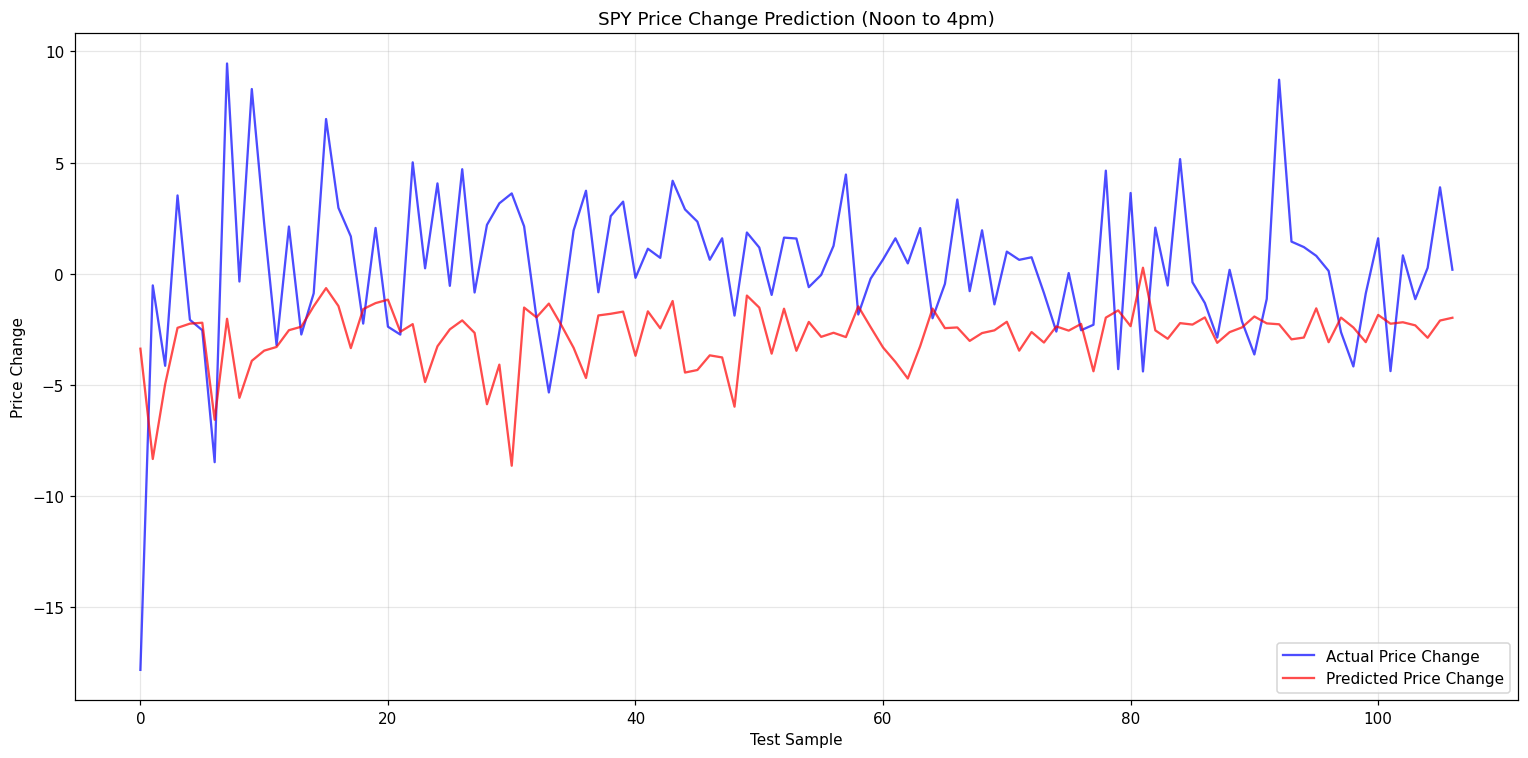

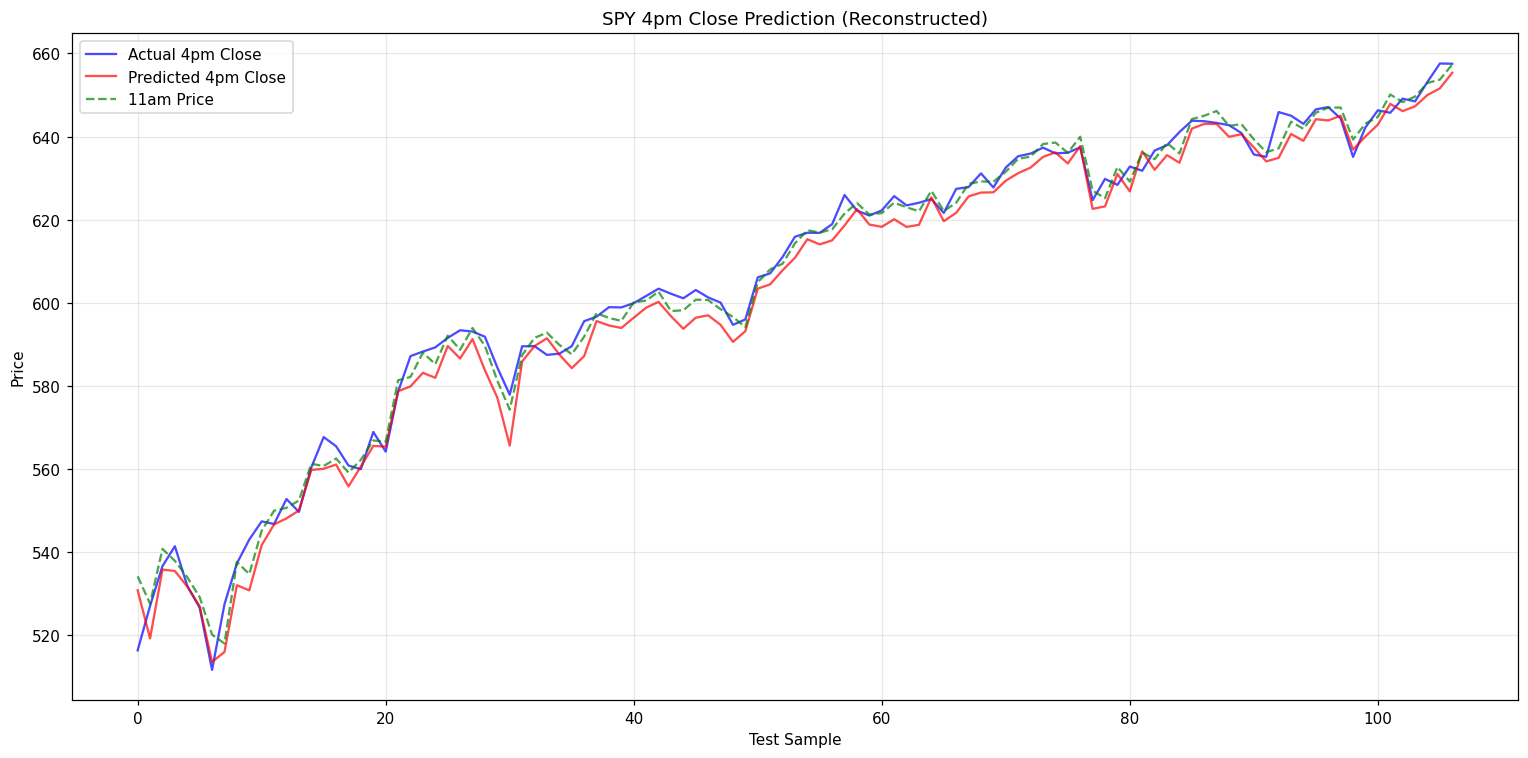

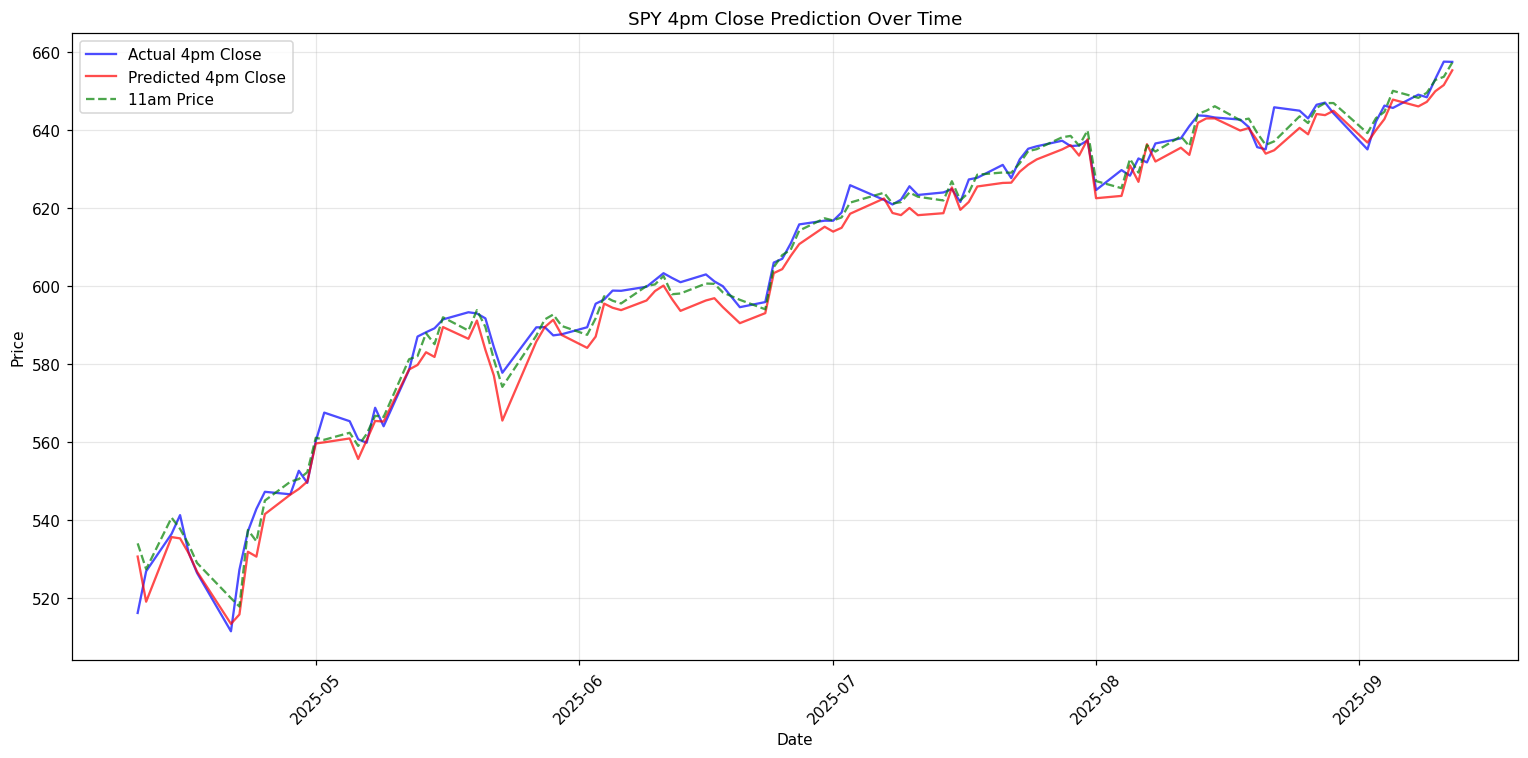

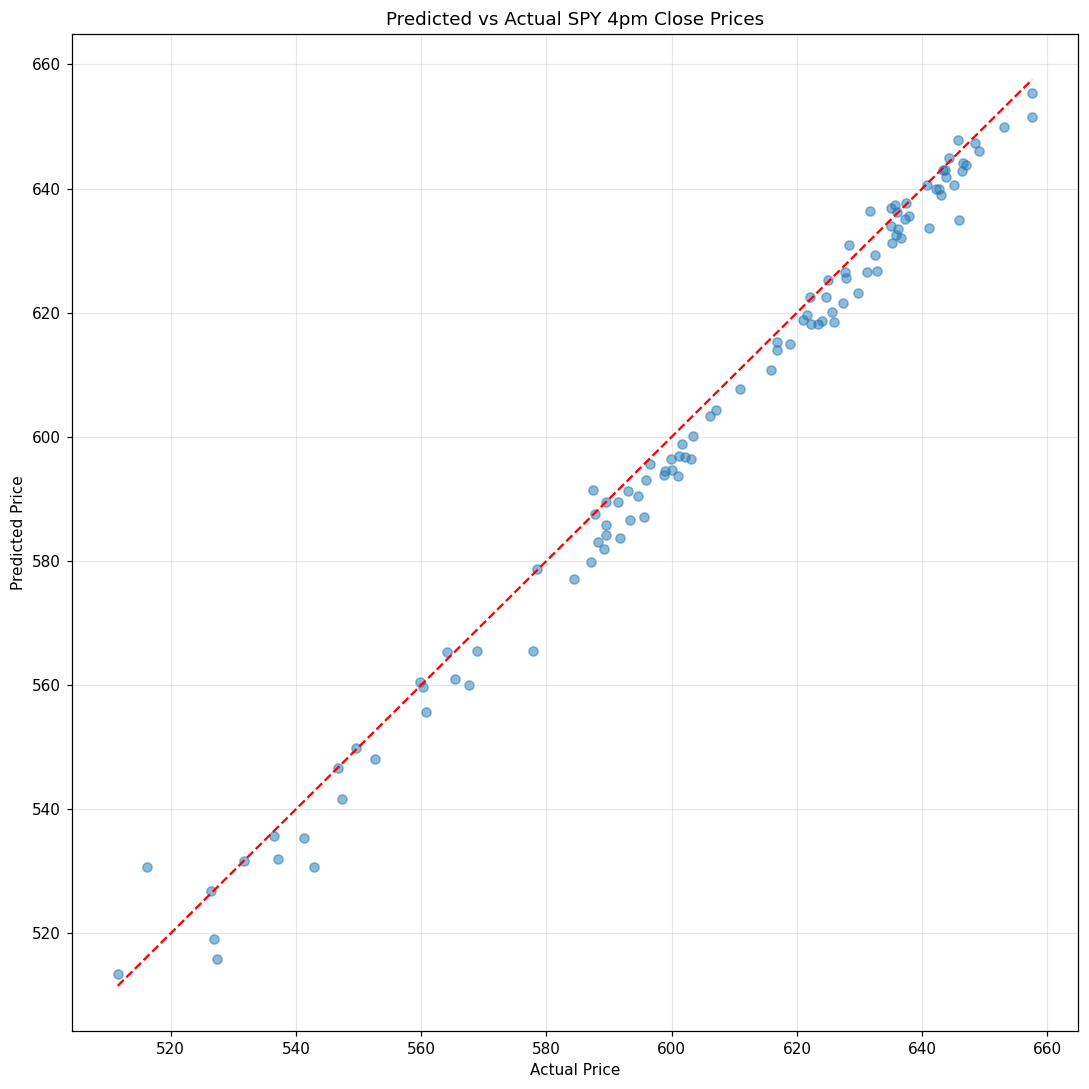

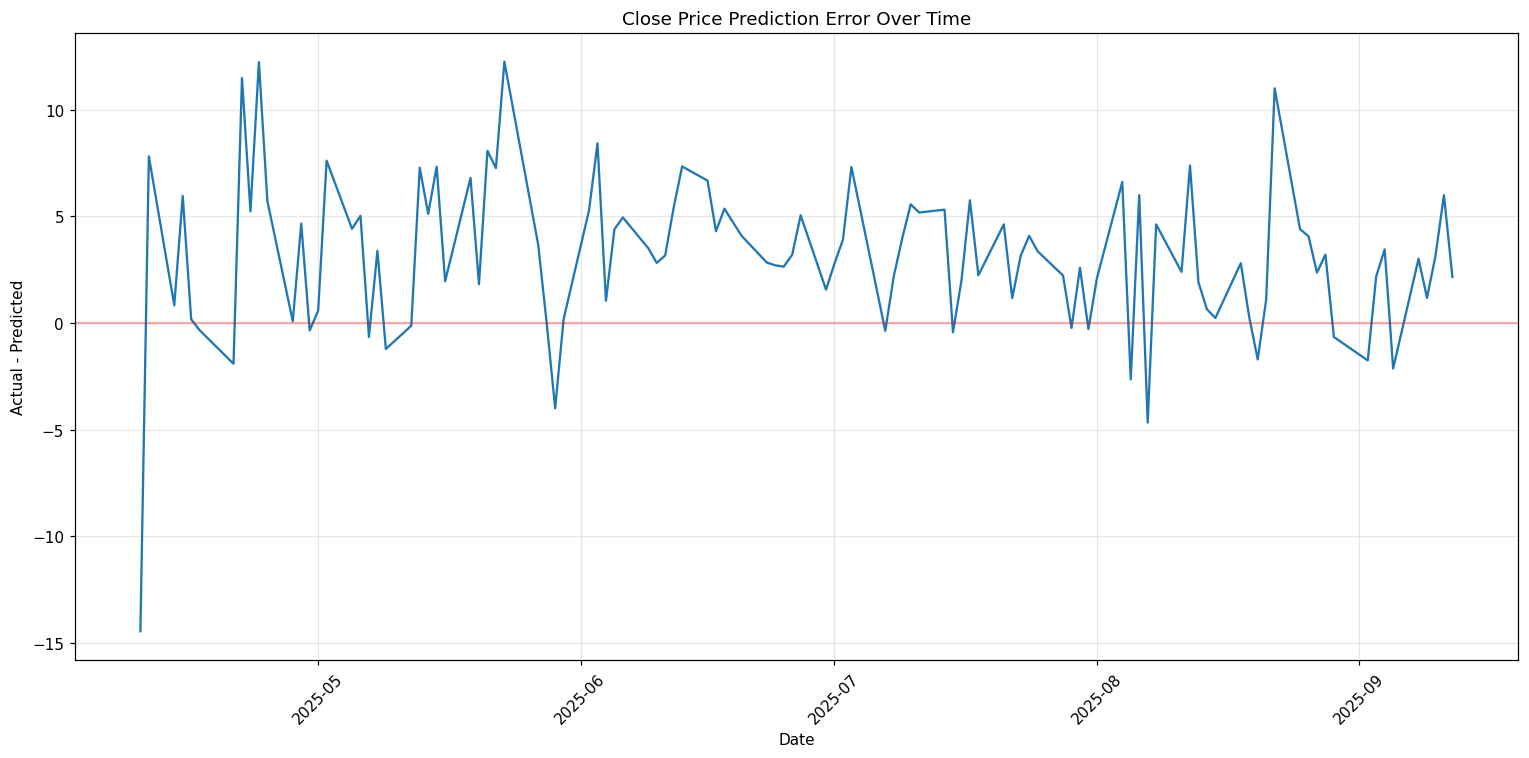

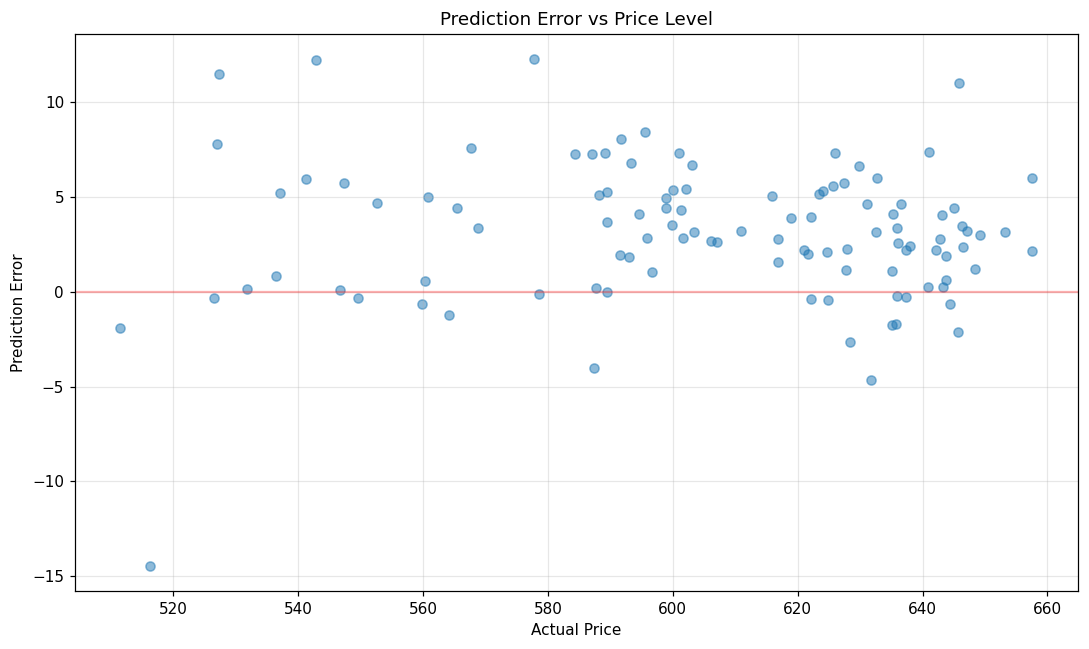

Model training and evaluation complete!


In [111]:
# Plot predictions - note the variable name change
plot_predictions(
    y_test,
    y_pred_changes,
    y_test_close,
    y_pred_close,
    test_reference_prices,  # Using reference_prices instead of noon_prices
    test_dates
)

print("Model training and evaluation complete!")

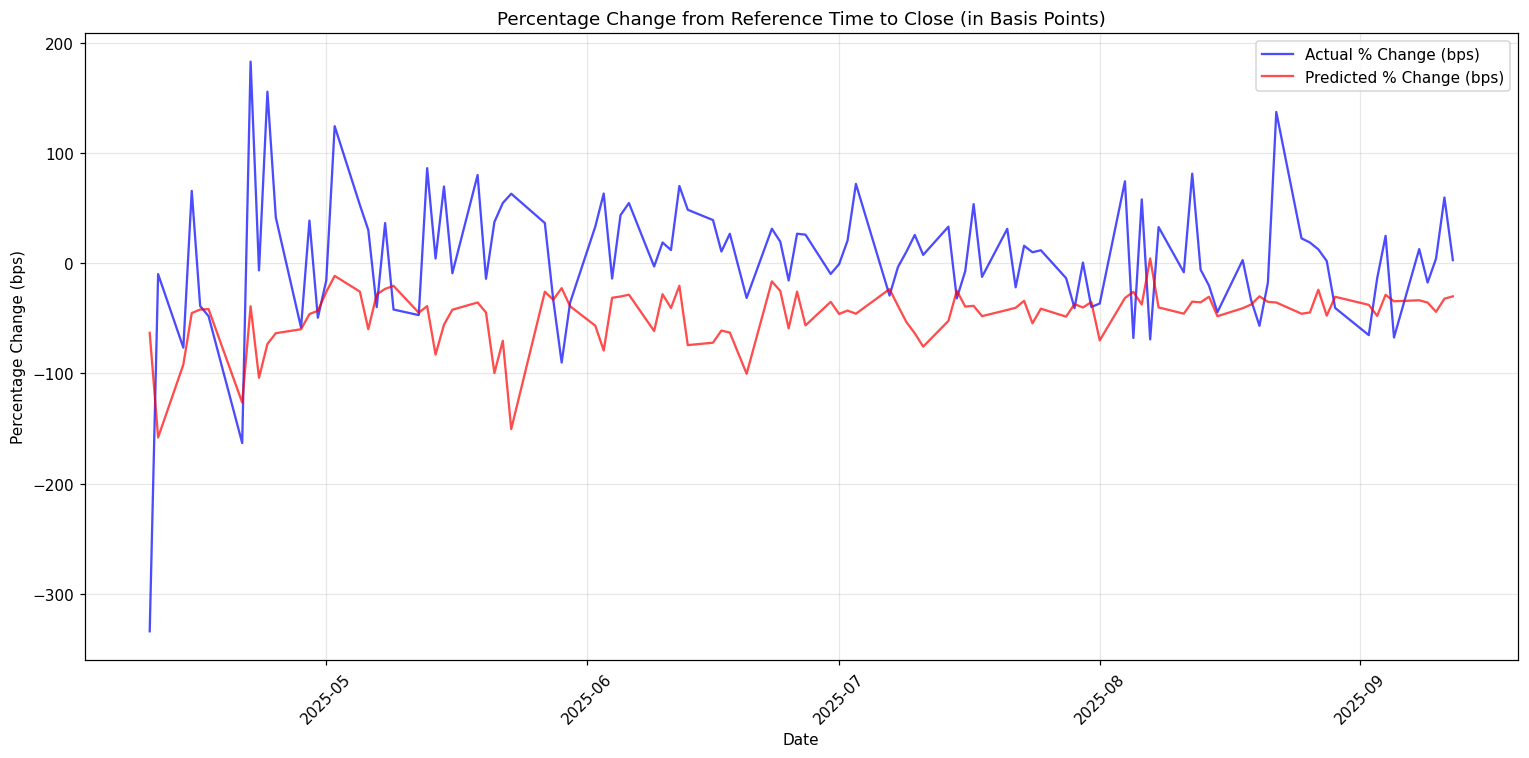

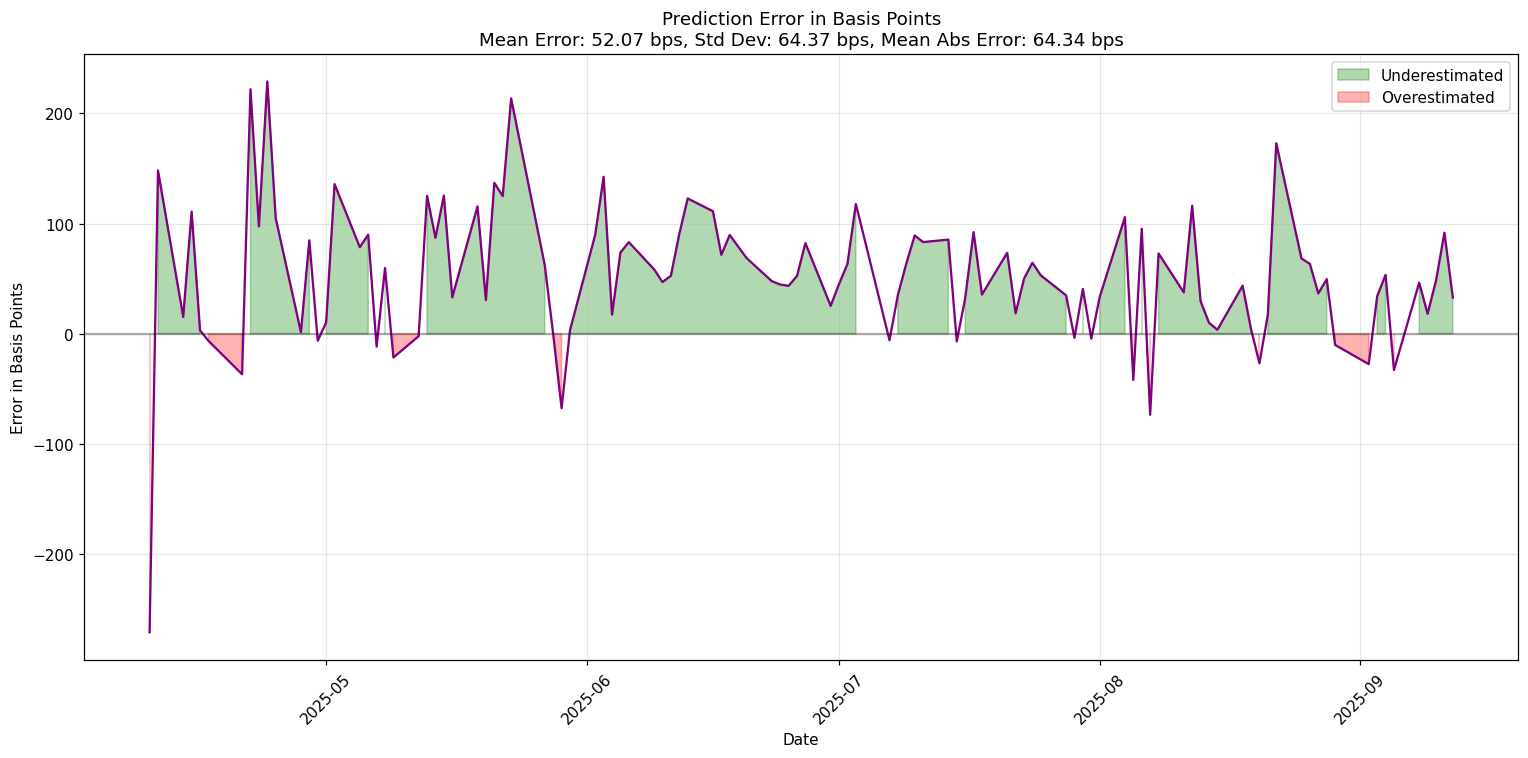

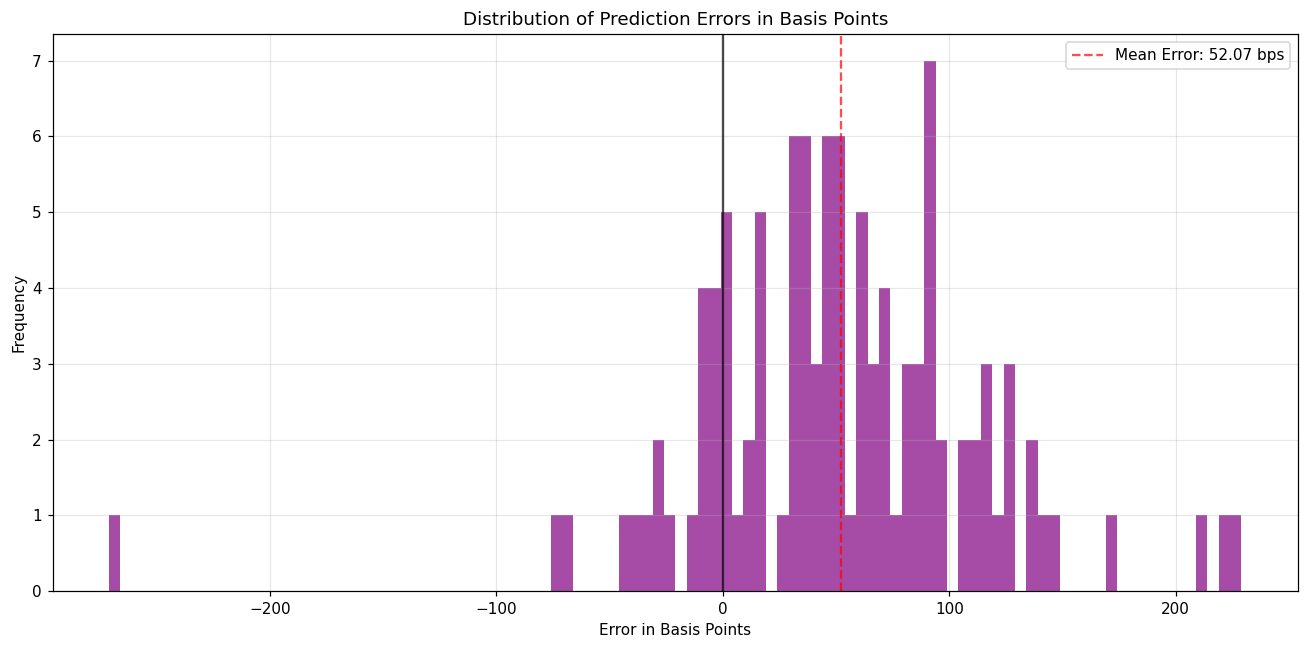

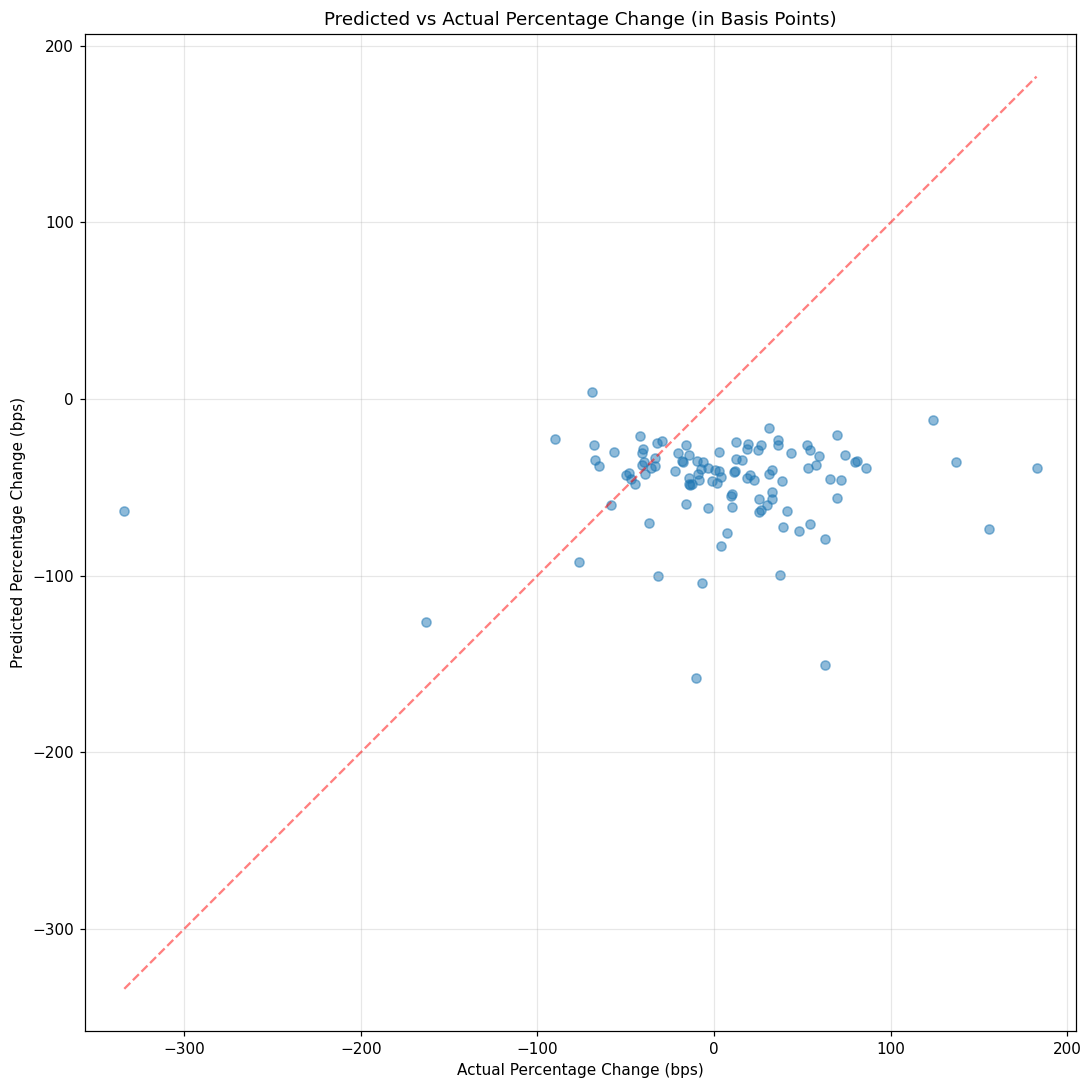

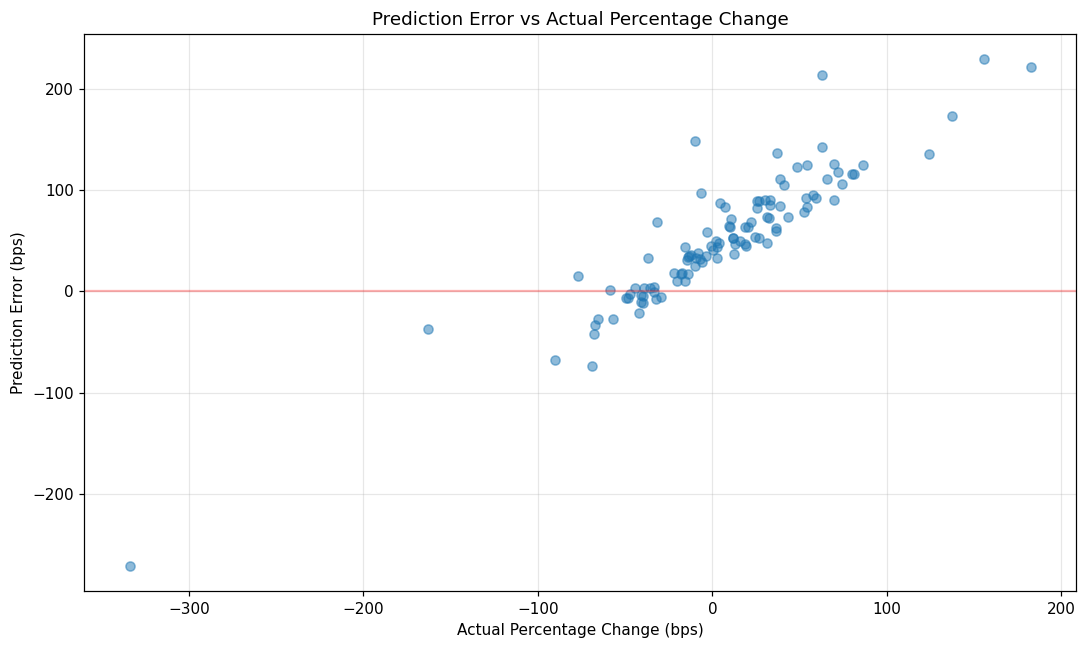


===== Percentage Basis Points Prediction Summary =====
Mean Percentage Change Error: 52.07 bps
Standard Deviation of Error: 64.37 bps
Mean Absolute Error (MAE): 64.34 bps
Min Error: -270.72 bps
Max Error: 228.89 bps
Directional Accuracy: 43.93%

Days with large prediction errors (>50 bps):
          date  reference_price  actual_close  predicted_close  \
0   2025-04-10         534.0900      516.2500       530.709110   
1   2025-04-11         527.4800      526.9500       519.134743   
3   2025-04-15         537.8100      541.3300       535.369016   
7   2025-04-22         517.9000      527.3600       515.867114   
8   2025-04-23         537.5340      537.1776       531.941513   
9   2025-04-24         534.6200      542.9300       530.692983   
10  2025-04-25         545.0600      547.3100       541.591431   
12  2025-04-29         550.5800      552.7000       548.032528   
15  2025-05-02         560.6499      567.6099       559.995687   
16  2025-05-05         562.4493      565.4084   

In [112]:
# After you've run your model and have the prediction results:

# First, make sure you have these variables from your model evaluation:
# - test_dates: dates in your test set
# - test_reference_prices: the 11 AM prices
# - y_pred_close: the predicted 4 PM close prices
# - y_test_close: the actual 4 PM close prices

# Now call the new function to plot percentage basis points:
results_df = plot_percentage_basis_points(
    test_dates,
    test_reference_prices,
    y_pred_close,
    y_test_close
)

# If you want to examine specific days with large errors:
large_errors = results_df[abs(results_df['prediction_error_bps']) > 50]
print("\nDays with large prediction errors (>50 bps):")
print(large_errors[['date', 'reference_price', 'actual_close', 'predicted_close', 'prediction_error_bps']])

# If you want to analyze performance by month:
results_df['month'] = pd.DatetimeIndex(results_df['date']).month
monthly_performance = results_df.groupby('month')['prediction_error_bps'].agg(['mean', 'std', 'count'])
print("\nMonthly prediction error analysis:")
print(monthly_performance)

# If you want to see the performance for up days vs down days:
up_days = results_df[results_df['actual_pct_change_bps'] > 0]
down_days = results_df[results_df['actual_pct_change_bps'] < 0]

print("\nPerformance on up days:")
print(f"Mean Error: {up_days['prediction_error_bps'].mean():.2f} bps")
print(f"Mean Absolute Error: {up_days['prediction_error_bps'].abs().mean():.2f} bps")
print(f"Number of up days: {len(up_days)}")

print("\nPerformance on down days:")
print(f"Mean Error: {down_days['prediction_error_bps'].mean():.2f} bps")
print(f"Mean Absolute Error: {down_days['prediction_error_bps'].abs().mean():.2f} bps")
print(f"Number of down days: {len(down_days)}")

<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Future Prediction
</div>

1. Set the inputs

In [141]:
# Set the stock symbol and prediction parameters
SYMBOL = "SPY"
timeframe = "minute"
interval = 5
start_date = '2023-01-01'
#end_date = '2023-01-05'
end_date = '2025-09-12'


features = [
    "open", "high", "low", "close", "volume",
    "momentum_5", "momentum_10", "stddev_10",
    "minutes_since_open", "vwap", "trade_count", 
    "relative_volume_30", 'high_since_open', 'low_since_open', 
    'cumulative_volume', 'open_at_930am', 'close_at_4pm', 
    'SMA_6', 'SMA_20', 'RSI', 'MACD_6_20_9', 
    'MACD_SIGNAL_6_20_9', 'MACD_HIST_6_20_9', 
    'Bollinger_High', 'Bollinger_Low', 'Volume_SMA_5' 
]


'''

# Define features for the model
features = [
    "open", "high", "low", "close", "volume",
    "momentum_5", "momentum_10", "stddev_10",
    "minutes_since_open"
]

'''

'\n\n# Define features for the model\nfeatures = [\n    "open", "high", "low", "close", "volume",\n    "momentum_5", "momentum_10", "stddev_10",\n    "minutes_since_open"\n]\n\n'

2. Setup and Run the Pipeline

Fetching data for SPY...
Successfully fetched 126903 data points for SPY.
First 5 rows of the dataset:
                            close    high     low  trade_count    open  \
timestamp                                                                
2023-01-03 09:00:00+00:00  386.51  386.54  384.00          289  384.00   
2023-01-03 09:05:00+00:00  385.96  386.53  385.91          182  386.50   
2023-01-03 09:10:00+00:00  386.51  386.51  386.13           70  386.18   
2023-01-03 09:15:00+00:00  386.28  386.79  386.28          106  386.54   
2023-01-03 09:20:00+00:00  386.70  386.70  386.48           40  386.48   

                           volume        vwap  
timestamp                                      
2023-01-03 09:00:00+00:00   26198  385.969810  
2023-01-03 09:05:00+00:00   50073  386.063871  
2023-01-03 09:10:00+00:00    7497  386.308841  
2023-01-03 09:15:00+00:00    8990  386.608430  
2023-01-03 09:20:00+00:00    3736  386.571053  
Creating technical indicator features...
F

c:\Users\Afiat_Trading\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 2370, 64)       │        23,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 2370, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,257 (141.63 KB)

 Trainable params: 36,257 (141.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step - loss: 0.8311 - mae: 0.3296 - val_loss: 2.3112 - val_mae: 0.8036 - learning_rate: 0.0010
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - loss: 0.2573 - mae: 0.2082 - val_loss: 0.4233 - val_mae: 0.3495 - learning_rate: 0.0010
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - loss: 0.0361 - mae: 0.1046 - val_loss: 0.1257 - val_mae: 0.1601 - learning_rate: 0.0010
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - loss: 0.0267 - mae: 0.0797 - val_loss: 0.1739 - val_mae: 0.1982 - learning_rate: 0.0010
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - loss: 0.0253 - mae: 0.0774 - val_loss: 0.1808 - val_mae: 0.2016 - learning_rate: 0.0010
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 59s 4s/step - loss: 0.0300 - mae: 0.0760 - val_loss: 0.1777 - val_mae: 0.1981 - learning_rate: 0.0010
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - loss: 0.0160 - mae: 0.0638 - val_loss: 0.1354 - val_mae: 0.1757 - learning_rate: 0.0010
Epoch 8/50
16/16 ━━━

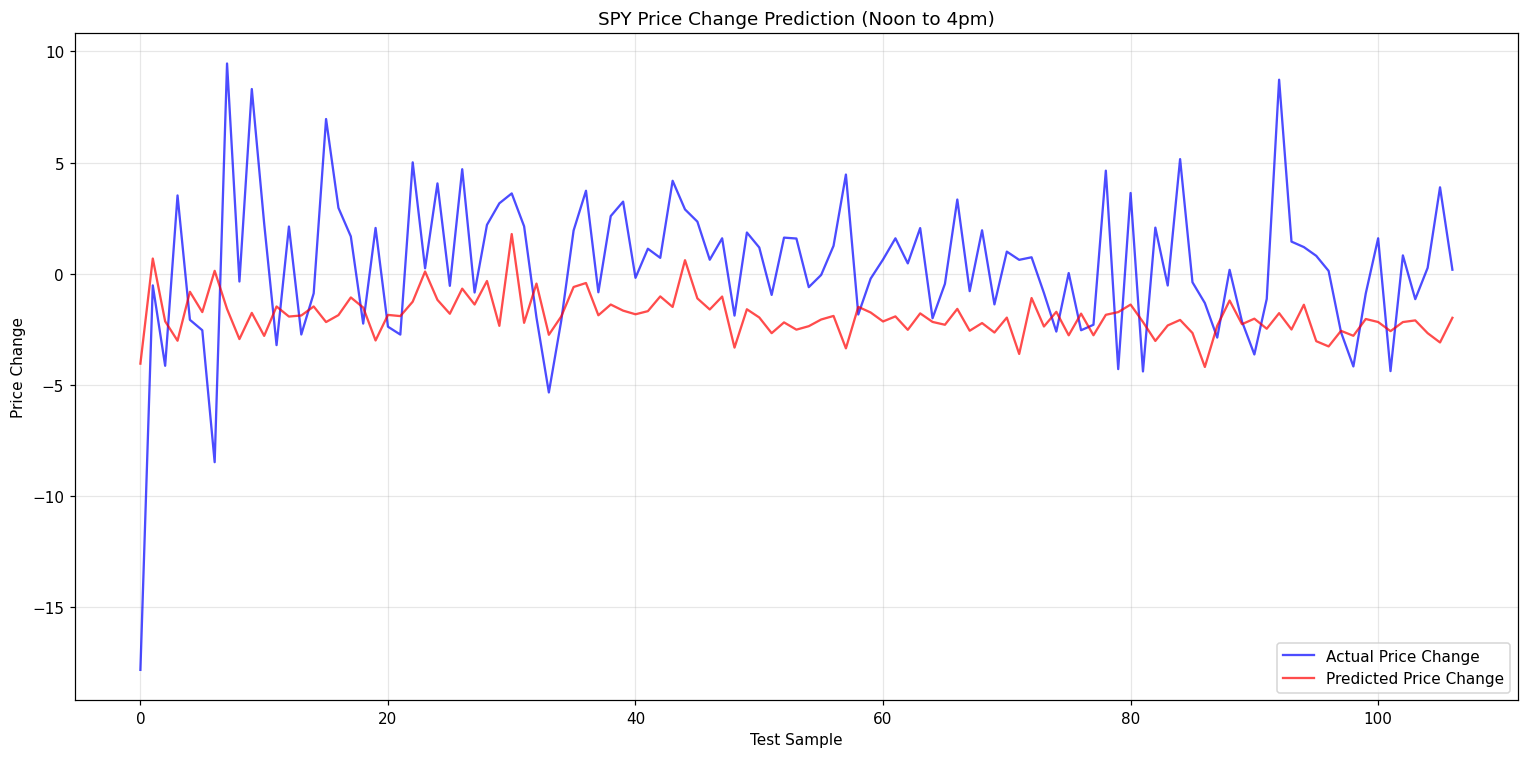

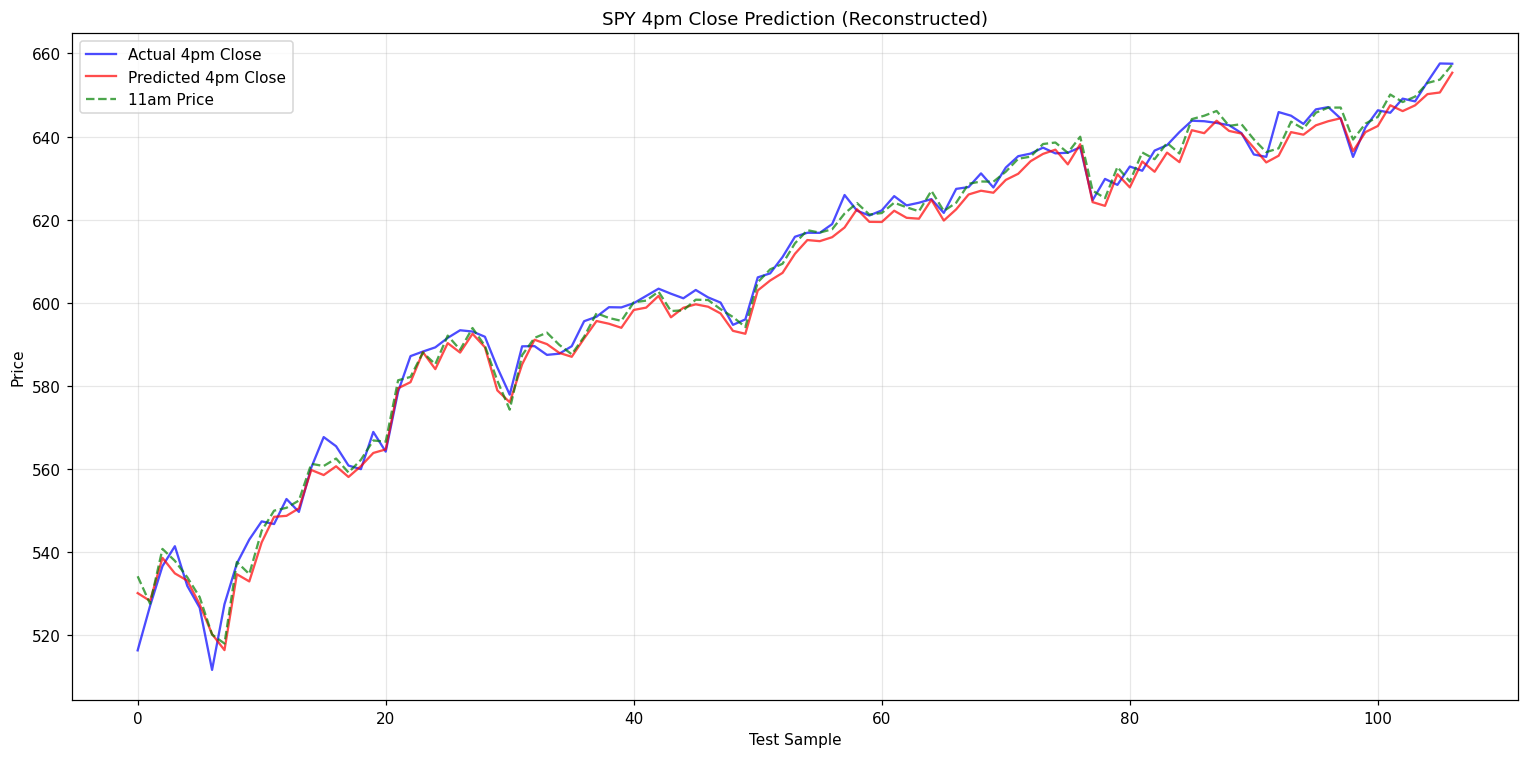

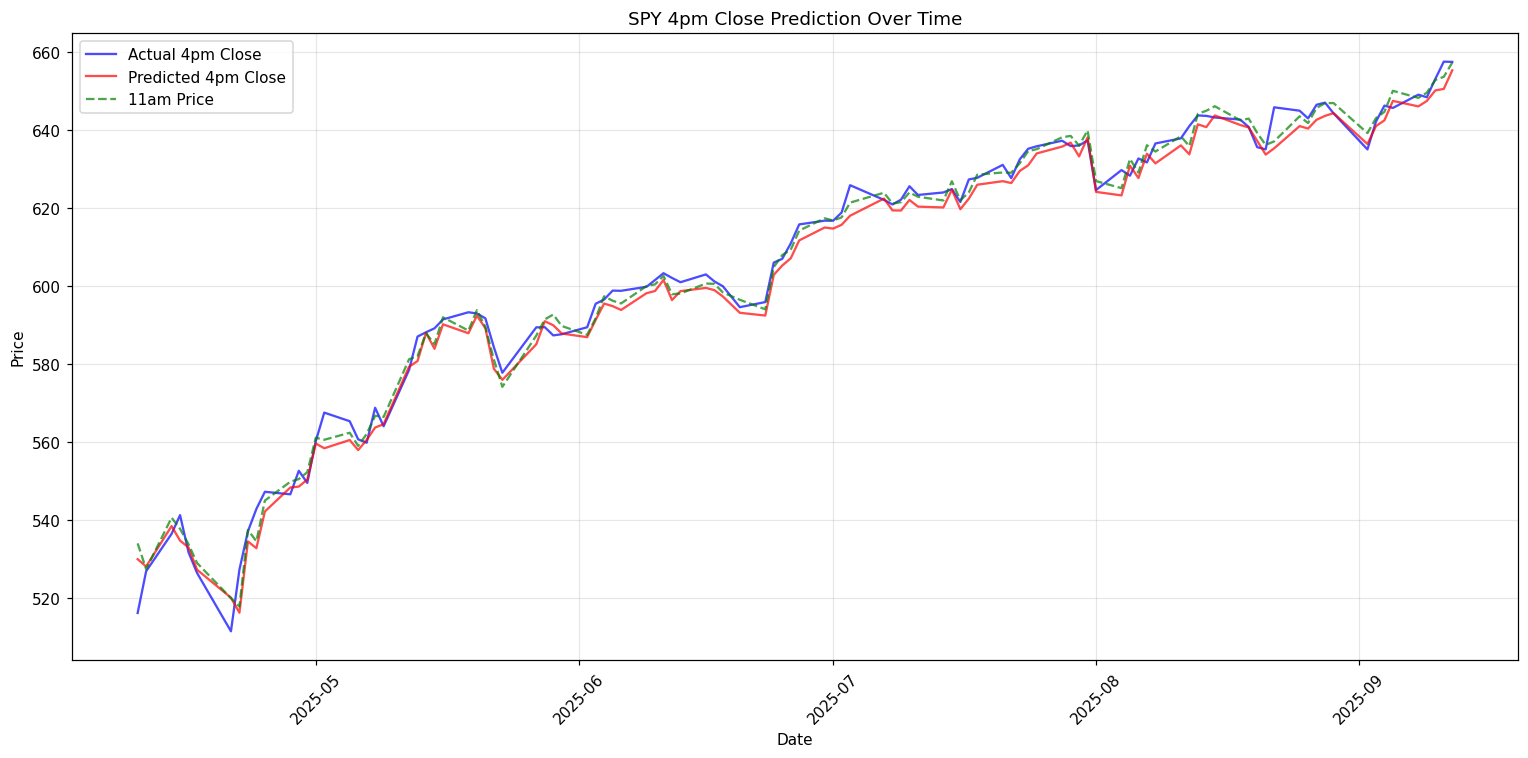

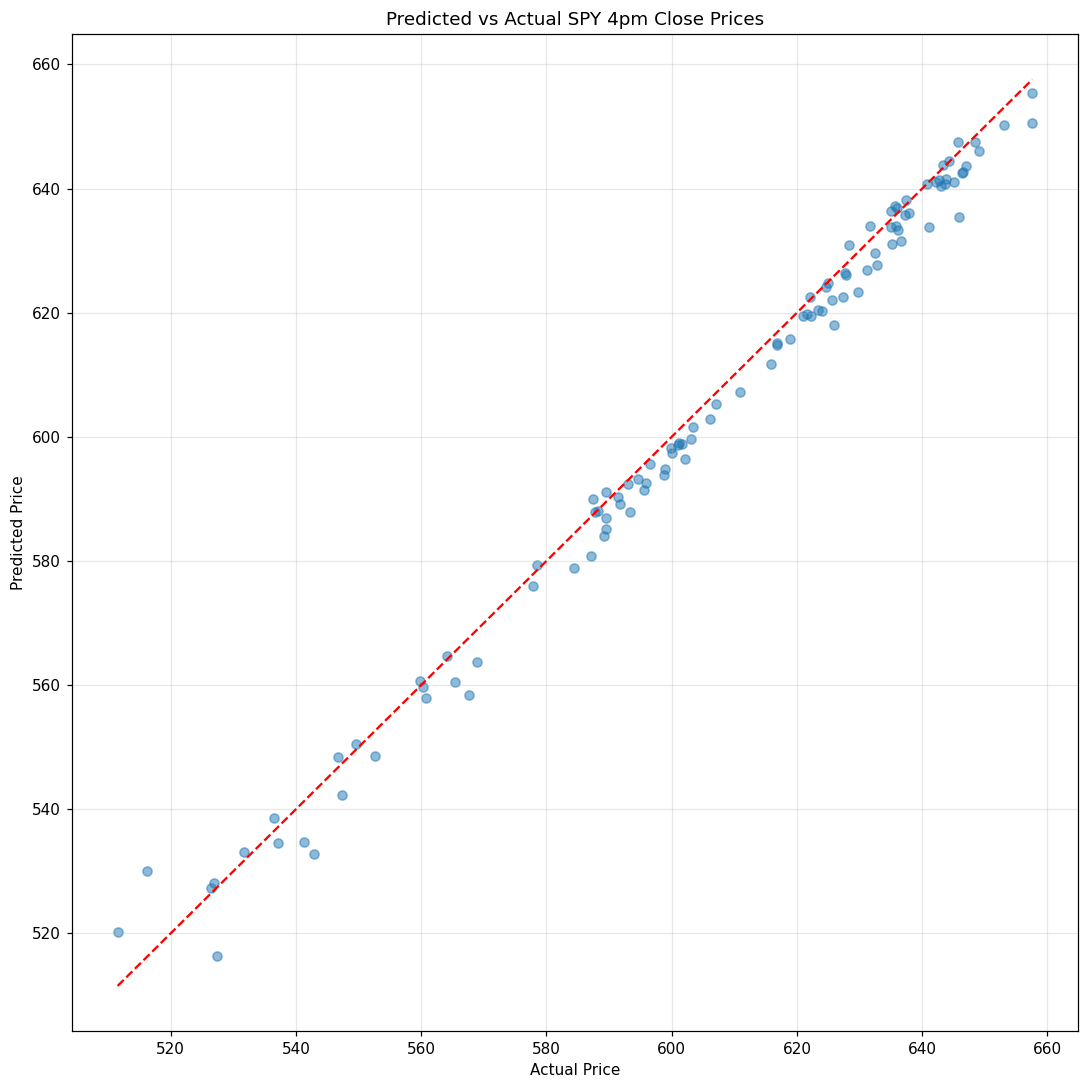

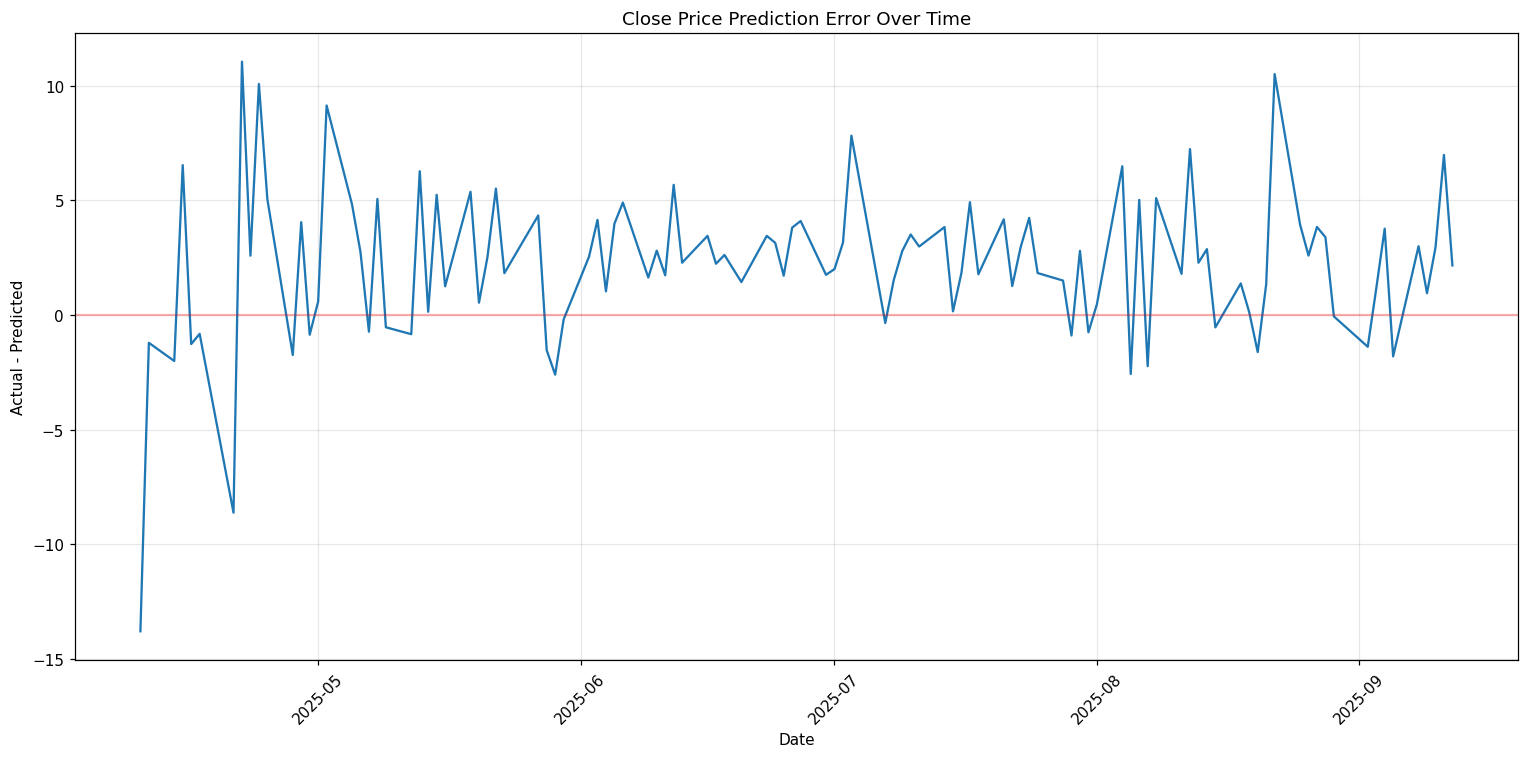

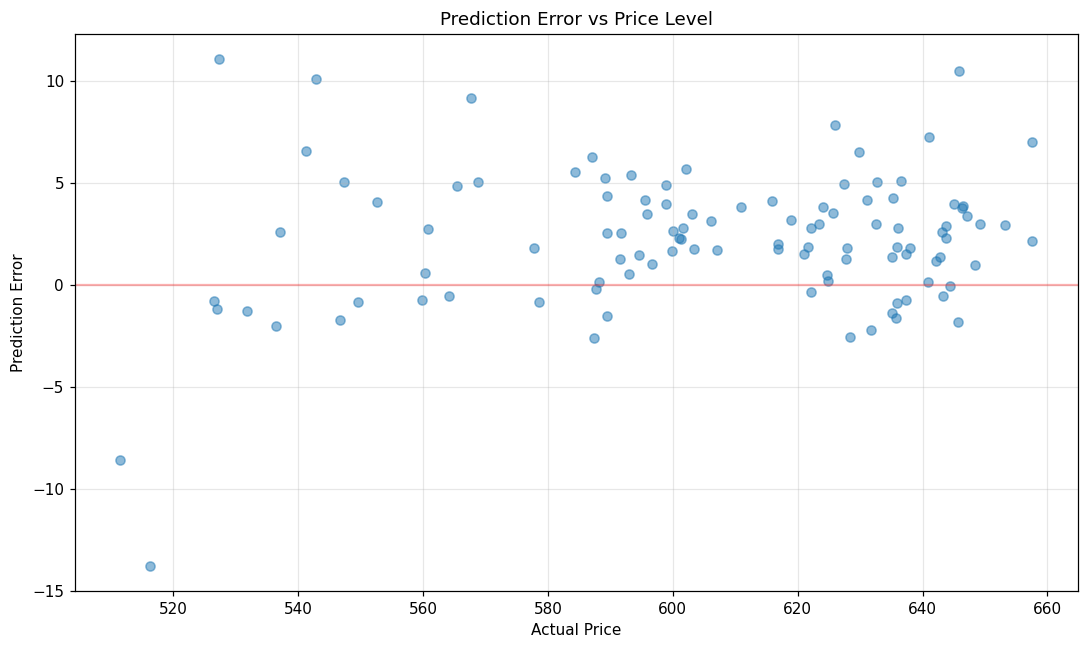

In [142]:
# --- Fetch the Data ---
try:

    stock_data = fetch_data(symbol=SYMBOL, timeframe=timeframe, interval=interval, bars_back=200, start_date=start_date, end_date=end_date)
    stock_data = create_features(stock_data)
    stock_data_preprocessed = load_and_preprocess_data_df(stock_data)
    stock_data_preprocessed_with_reference = calculate_reference_prices(stock_data_preprocessed, reference_hour=12, reference_minute=0)
    
    X, y, dates, reference_prices = build_lstm_sequences(
        stock_data_preprocessed_with_reference,
        features,
        lookback_days=6,
        cutoff_time=time(12, 0)
    )

    (X_train, y_train, train_dates, train_reference_prices,
    X_val, y_val, val_dates, val_reference_prices,
    X_test, y_test, test_dates, test_reference_prices) = split_dataset(
        X, y, dates, reference_prices, train_ratio=0.7, val_ratio=0.15
    )

    feature_scaler, target_scaler, X_train_scaled, y_train_scaled, X_val_scaled, y_val_scaled, X_test_scaled, y_test_scaled = scale_data(
    X_train, y_train, X_val, y_val, X_test, y_test
    )

    input_shape = (X_train_scaled.shape[1], X_train_scaled.shape[2])
    model = create_lstm_model(input_shape)
    model.summary()


    model, history = train_model(
        model,
        X_train_scaled, y_train_scaled,
        X_val_scaled, y_val_scaled,
        epochs=50,
        batch_size=32
    )
    
    y_pred_changes, y_pred_close, y_test_close = evaluate_model(
        model,
        target_scaler,
        X_test_scaled,
        y_test,
        test_reference_prices  # Using reference_prices instead of noon_prices
    )

    plot_predictions(
        y_test,
        y_pred_changes,
        y_test_close,
        y_pred_close,
        test_reference_prices,  # Using reference_prices instead of noon_prices
        test_dates
    )


except Exception as e:
    print(f"An error occurred while fetching data: {e}")
    print("Please ensure your API keys are correct and have the necessary permissions.")

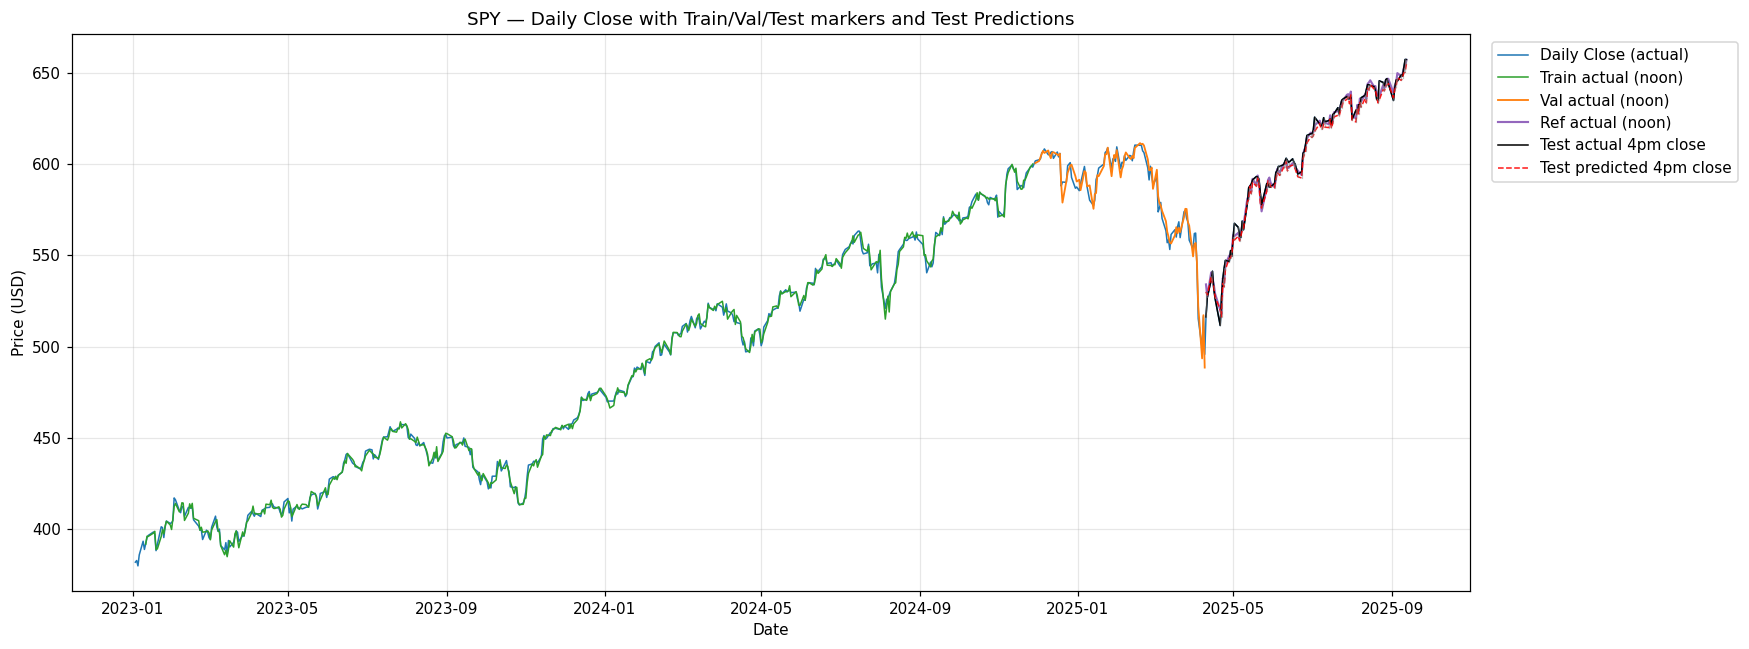

In [150]:
import pandas as pd
import numpy as np

# Clean plotting cell — drop nulls and zero closes before plotting
import matplotlib.pyplot as plt

# Assumes these variables exist: stock_data_preprocessed_with_reference, train_dates, val_dates, test_dates,
# train_reference_prices, val_reference_prices, test_reference_prices, y_test_close, y_pred_close, SYMBOL

df_all = stock_data_preprocessed_with_reference.copy()

# Build daily_close (prefer close_at_4pm, else daily last close)
if 'close_at_4pm' in df_all.columns and df_all['close_at_4pm'].notna().any():
    daily = df_all[['trade_date', 'close_at_4pm']].drop_duplicates('trade_date').set_index('trade_date')
    daily.index = pd.to_datetime(daily.index)
    daily_close = daily['close_at_4pm'].sort_index()
else:
    if 'timestamp' in df_all.columns:
        df_all['timestamp'] = pd.to_datetime(df_all['timestamp'], errors='coerce')
        daily_close = df_all.set_index('timestamp').close.resample('1D').last().dropna()
    else:
        df_all['trade_date'] = pd.to_datetime(df_all['trade_date'])
        daily_close = df_all.groupby('trade_date')['close'].last()
        daily_close.index = pd.to_datetime(daily_close.index)
        daily_close = daily_close.sort_index()

# Drop any nulls and zero values in daily series
daily_close = daily_close.dropna()
daily_close = daily_close[daily_close != 0]

def to_dt_index(dates):
    if dates is None:
        return pd.DatetimeIndex([])
    return pd.to_datetime(dates)

train_idx = to_dt_index(train_dates)
val_idx = to_dt_index(val_dates)
test_idx = to_dt_index(test_dates)

# Build DataFrames and align lengths to indices; then drop NaNs and zero values
def build_df(values, idx, col_name):
    if len(idx) == 0 or values is None:
        return pd.DataFrame(columns=[col_name]).astype(float)
    # If numpy array length mismatches, try to align by trimming/padding
    arr = np.asarray(values)
    if len(arr) != len(idx):
        arr = arr[:len(idx)]
    df = pd.DataFrame({col_name: arr}, index=idx)
    df.index = pd.to_datetime(df.index)
    # remove zero close prices and NaNs
    df = df.replace(0, np.nan)
    return df.dropna()

# Build train/val/test marker dataframes (column kept as 'reference_price' for numeric handling)
train_df = build_df(train_reference_prices if 'train_reference_prices' in globals() else None, train_idx, 'reference_price')
val_df = build_df(val_reference_prices if 'val_reference_prices' in globals() else None, val_idx, 'reference_price')
test_ref_df = build_df(test_reference_prices if 'test_reference_prices' in globals() else None, test_idx, 'reference_price')
test_actual_df = build_df(y_test_close if 'y_test_close' in globals() else None, test_idx, 'actual_close')
test_pred_df = build_df(y_pred_close if 'y_pred_close' in globals() else None, test_idx, 'predicted_close')

# Restrict marker points to dates that exist in daily_close to avoid plotting outside range
common_index = daily_close.index
train_df = train_df[train_df.index.isin(common_index)]
val_df = val_df[val_df.index.isin(common_index)]
test_ref_df = test_ref_df[test_ref_df.index.isin(common_index)]
test_actual_df = test_actual_df[test_actual_df.index.isin(common_index)]
test_pred_df = test_pred_df[test_pred_df.index.isin(common_index)]

# Plot
plt.figure(figsize=(16,6))
# Plot the daily close as a line
plt.plot(daily_close.index, daily_close.values, label='Daily Close (actual)', color='tab:blue', linewidth=1)

# Plot train/val/test reference as lines (no dot markers) — labels changed to "actual"/"ref actual"
if not train_df.empty:
    plt.plot(train_df.index, train_df['reference_price'],
             color='tab:green', linestyle='-', linewidth=1.0,
             label='Train actual (noon)')
if not val_df.empty:
    plt.plot(val_df.index, val_df['reference_price'],
             color='tab:orange', linestyle='-', linewidth=1.2,
             label='Val actual (noon)')
if not test_ref_df.empty:
    plt.plot(test_ref_df.index, test_ref_df['reference_price'],
             color='tab:purple', linestyle='-', linewidth=1.4,
             label='Ref actual (noon)')

# Plot test actual & predicted closes as lines (connect points)
if not test_actual_df.empty:
    plt.plot(test_actual_df.index, test_actual_df['actual_close'],
             color='black', linestyle='-', linewidth=1.0,
             label='Test actual 4pm close')
if not test_pred_df.empty:
    plt.plot(test_pred_df.index, test_pred_df['predicted_close'],
             color='red', linestyle='--', linewidth=1.0, alpha=0.9,
             label='Test predicted 4pm close')

# Connect predicted vs actual on test set (only where both exist)
if (not test_actual_df.empty) and (not test_pred_df.empty):
    merged = pd.concat([test_actual_df, test_pred_df], axis=1).dropna().sort_index()
    for dt, row in merged.iterrows():
        plt.plot([dt, dt], [row['actual_close'], row['predicted_close']], color='gray', alpha=0.5, linewidth=0.8)

plt.title(f"{SYMBOL} — Daily Close with Train/Val/Test markers and Test Predictions")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [177]:
import pandas as pd
import numpy as np

# Clean plotting cell — drop nulls and zero closes before plotting
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource, HoverTool, DatetimeTickFormatter
from bokeh.palettes import Category10

output_notebook()

# Assumes these variables exist: stock_data_preprocessed_with_reference, train_dates, val_dates, test_dates,
# train_reference_prices, val_reference_prices, test_reference_prices, y_test_close, y_pred_close, SYMBOL

df_all = stock_data_preprocessed_with_reference.copy()

# Build daily_close (prefer close_at_4pm, else daily last close)
if 'close_at_4pm' in df_all.columns and df_all['close_at_4pm'].notna().any():
    daily = df_all[['trade_date', 'close_at_4pm']].drop_duplicates('trade_date').set_index('trade_date')
    daily.index = pd.to_datetime(daily.index)
    daily_close = daily['close_at_4pm'].sort_index()
else:
    if 'timestamp' in df_all.columns:
        df_all['timestamp'] = pd.to_datetime(df_all['timestamp'], errors='coerce')
        daily_close = df_all.set_index('timestamp').close.resample('1D').last().dropna()
    else:
        df_all['trade_date'] = pd.to_datetime(df_all['trade_date'])
        daily_close = df_all.groupby('trade_date')['close'].last()
        daily_close.index = pd.to_datetime(daily_close.index)
        daily_close = daily_close.sort_index()

# Drop any nulls and zero values in daily series
daily_close = daily_close.dropna()
daily_close = daily_close[daily_close != 0]

def to_dt_index(dates):
    if dates is None:
        return pd.DatetimeIndex([])
    return pd.to_datetime(dates)

train_idx = to_dt_index(train_dates)
val_idx = to_dt_index(val_dates)
test_idx = to_dt_index(test_dates)

# Build DataFrames and align lengths to indices; then drop NaNs and zero values
def build_df(values, idx, col_name):
    if len(idx) == 0 or values is None:
        return pd.DataFrame(columns=[col_name]).astype(float)
    arr = np.asarray(values)
    if len(arr) != len(idx):
        arr = arr[:len(idx)]
    df = pd.DataFrame({col_name: arr}, index=idx)
    df.index = pd.to_datetime(df.index)
    df = df.replace(0, np.nan)
    return df.dropna()

train_df = build_df(train_reference_prices if 'train_reference_prices' in globals() else None, train_idx, 'reference_price')
val_df = build_df(val_reference_prices if 'val_reference_prices' in globals() else None, val_idx, 'reference_price')
test_ref_df = build_df(test_reference_prices if 'test_reference_prices' in globals() else None, test_idx, 'reference_price')
test_actual_df = build_df(y_test_close if 'y_test_close' in globals() else None, test_idx, 'actual_close')
test_pred_df = build_df(y_pred_close if 'y_pred_close' in globals() else None, test_idx, 'predicted_close')

common_index = daily_close.index
train_df = train_df[train_df.index.isin(common_index)]
val_df = val_df[val_df.index.isin(common_index)]
test_ref_df = test_ref_df[test_ref_df.index.isin(common_index)]
test_actual_df = test_actual_df[test_actual_df.index.isin(common_index)]
test_pred_df = test_pred_df[test_pred_df.index.isin(common_index)]

# Prepare Bokeh figure
p = figure(x_axis_type='datetime', width=900, height=420,
           title=f"{SYMBOL} — Daily Close with Train/Val/Test markers and Test Predictions",
           tools="pan,wheel_zoom,box_zoom,reset,save")

p.xaxis.axis_label = "Date"
p.yaxis.axis_label = "Price (USD)"
p.xaxis.formatter = DatetimeTickFormatter(days="%Y-%m-%d")

palette = Category10[10]
# Daily close line
daily_src = ColumnDataSource({
    'date': daily_close.index.to_pydatetime(),
    'close': daily_close.values
})
p.line('date', 'close', source=daily_src, color=palette[0], line_width=2, legend_label='Daily Close (actual)')

# Train / Val / Test reference lines
if not train_df.empty:
    src = ColumnDataSource({'date': train_df.index.to_pydatetime(), 'ref': train_df['reference_price'].values})
    p.line('date', 'ref', source=src, color='green', line_width=1.0, legend_label='Train actual (noon)')

if not val_df.empty:
    src = ColumnDataSource({'date': val_df.index.to_pydatetime(), 'ref': val_df['reference_price'].values})
    p.line('date', 'ref', source=src, color='orange', line_width=1.2, legend_label='Val actual (noon)')

if not test_ref_df.empty:
    src = ColumnDataSource({'date': test_ref_df.index.to_pydatetime(), 'ref': test_ref_df['reference_price'].values})
    p.line('date', 'ref', source=src, color='purple', line_width=1.4, legend_label='Ref actual (noon)')

# Test actual & predicted closes
if not test_actual_df.empty:
    src = ColumnDataSource({'date': test_actual_df.index.to_pydatetime(), 'actual': test_actual_df['actual_close'].values})
    p.line('date', 'actual', source=src, color='black', line_width=1.5, legend_label='Test actual 4pm close')
    p.circle('date', 'actual', source=src, color='black', size=6, alpha=0.6)

if not test_pred_df.empty:
    src = ColumnDataSource({'date': test_pred_df.index.to_pydatetime(), 'pred': test_pred_df['predicted_close'].values})
    p.line('date', 'pred', source=src, color='red', line_width=1.5, line_dash='dashed', alpha=0.9, legend_label='Test predicted 4pm close')
    p.triangle('date', 'pred', source=src, color='red', size=6, alpha=0.6)

# Vertical connectors between actual and predicted on test set (where both exist)
if (not test_actual_df.empty) and (not test_pred_df.empty):
    merged = pd.concat([test_actual_df, test_pred_df], axis=1).dropna().sort_index()
    if not merged.empty:
        seg_src = ColumnDataSource({
            'date': merged.index.to_pydatetime(),
            'actual': merged['actual_close'].values,
            'pred': merged['predicted_close'].values
        })
        p.segment(x0='date', x1='date', y0='actual', y1='pred', source=seg_src, color='gray', line_width=1, alpha=0.5)

# Hover tool for daily close and test points
hover = HoverTool(tooltips=[('Date', '@date{%F}'), ('Price', '$@close{0.2f}')],
                  formatters={'@date': 'datetime'}, mode='vline', renderers=[p.renderers[0]])
p.add_tools(hover)

p.legend.location = "top_left"
p.legend.click_policy = "hide"

show(p)

Loading BokehJS ...

<div style="background-color: purple; color: white; padding: 10px; border-square: 10px; text-align: center; font-size: 24px; font-weight: bold; max-width: 90%; margin: auto;">
    Conclusion
</div>